In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glasbey
import seaborn as sns
import anndata as ad
import gc
from sklearn.preprocessing import QuantileTransformer
from tqdm import tqdm
from sklearn.neighbors import KDTree
from scipy.spatial import cKDTree

dir = '/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/PythonIMC'
sys.path.append(os.path.abspath(dir))
from pythonimc import assembling, compensation, convert_to_fcs, mcd_preprocessing, merging, plotting, scdata
from pythonimc import scneighbors, segmentation, tissuezones3, phenotyping, polarity

base_dir = '/Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis'

/Users/jeinhaus/miniconda3/envs/OSCCRecurrence/lib/python3.10/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
Seed set to 0


# Preprocessing

## MCD conversion

1. Convert MCD to TIFF: 
    - base_dir needs a folder "raw" with MCD files. 
    - choose HPF (hot pixel filter) threshold
2. Create panel from MCD files

In [ ]:
mcd_preprocessing.convert_mcd_to_tiff(base_dir, hpf=50)
mcd_preprocessing.create_panel_csv(base_dir)

## Project-specific adjustments

In [ ]:
# Swapped antibody names for Bi209 and Gd158
panel = pd.read_csv(os.path.join(base_dir, 'panel.csv'))
panel.loc[panel['channel'] == "Bi209", 'name'] = "Bi209_CD138"
panel.loc[panel['channel'] == "Bi209", 'marker'] = "CD138"
panel.loc[panel['channel'] == "Gd158", 'name'] = "Gd158_Neurofilament"
panel.loc[panel['channel'] == "Gd158", 'marker'] = "Neurofilament"
panel.to_csv(os.path.join(base_dir, 'panel.csv'), index=False)

In [ ]:
mcd_preprocessing.stitch_images(
    base_dir=base_dir,
    img_folder="img",
    img_top_name="20240808_OSCC_TMA_Tubingen_AB_A06.tiff",
    img_bottom_name="20240808_OSCC_TMA_Tubingen_AB_A06 - split.tiff",
    new_img_name="20240808_OSCC_TMA_Tubingen_AB_A06_new.tiff",
    visualize_channel_index=43,
)

mcd_preprocessing.archive_images(base_dir=base_dir, img_folder="img", 
                                 filenames=["20240808_OSCC_TMA_Tubingen_AB_A10old.tiff"])

# Image compensation

In [ ]:
import importlib
importlib.reload(compensation)
compensation.batch_compensate_images(base_dir, spillover_filename="spillovermatrix.csv", overwrite=False, backend="loky")

# Segmentation

## CellSAM

In [ ]:
segmentation.segment_imgs_cellsam(base_dir=base_dir, 
                          input_folder = 'img_comp', 
                          output_folder = "masks_muscle_cellsam",
                          nuclear_marker = '196Pt_Desmin')

## Mesmer

In [ ]:
segmentation.segment_imgs(base_dir=base_dir, 
                          input_folder = 'img_comp', 
                          output_folder = "masks_muscle",
                          markers = ['196Pt_Desmin'],
                          postprocess_kwargs = {
                                    'maxima_threshold': 0.075, # before 0.05
                                    'interior_threshold': 0.2, # before 0.15, 0.175
                                    'interior_smooth': 2,
                                    'small_objects_threshold': 60, # before 50
                                    'fill_holes_threshold': 30,
                                    'radius': 12
                                })

segmentation.segment_imgs(base_dir=base_dir, 
                          input_folder = 'img_comp', 
                          output_folder = "masks_vessel",
                          markers = ['160Gd_CD31'],
                          upper_bound=99.9,
                          postprocess_kwargs = {
                                    'maxima_threshold': 0.075, #before 0.05, 0.075, 0.15, 0.225
                                    'interior_threshold': 0.2, #before:0.15, 0.1,0.12, 0.09
                                    'interior_smooth': 2, #before 0.1, 1
                                    'small_objects_threshold': 15,
                                    'fill_holes_threshold': 15,
                                    'radius': 4 #before:10
                                })

segmentation.segment_imgs(base_dir=base_dir, 
                          input_folder = 'img_comp', 
                          output_folder = "masks_cells",
                          markers = ['161Dy_MPO', '162Dy_CD8a', '158Gd_CD138', '191Ir_DNA1', '193Ir_DNA2'], 
                          membrane_markers=['89Y_PanCK'],
                          image_mpp=0.8,
                          upper_bound=99,
                          postprocess_kwargs = {
                                'maxima_threshold': 0.075,
                                'interior_threshold': 0.05,
                                'interior_smooth': 2, 
                                'small_objects_threshold': 15,
                                'fill_holes_threshold': 15,
                                'radius': 2
                            })

## Merging masks

In [ ]:
merging.combine_masks(base_dir = base_dir,
                      masks_cells_folder= "masks_cells",
                      masks_muscle_folder = "masks_muscle",
                      masks_vessel_folder= "masks_vessel",
                      masks_merged_folder= "masks_merged",
                      size_threshold=20)

# Tissue zones

In [ ]:
import importlib
importlib.reload(tissuezones3)
tissuezones3.batch_generate_compartment_masks(base_dir=base_dir,
                                              tissue_channel=[0,1],
                                              tumor_channel=0,
                                              muscle_channel=46,
                                              overwrite=False,
                                              plot=False,
                                              img_folder= "img_comp",
                                              mask_folder= "masks_compartments")
tissuezones3.zonal_areas_table(base_dir)

,Image,Stromacore,Stromaborder,Tumorborder,Tumorcore,Stromamuscle
0,A01,1953958,360349,88300,172,14399
1,A02,1827489,273701,369759,75226,1233
2,A03,1545449,341541,296950,155939,331415
3,A04,1559810,149276,146167,71694,60362
4,A05,646592,670269,709284,444781,0
...,...,...,...,...,...,...
612,T71,1875193,128890,146196,244193,127564
613,T72,1541561,118182,187234,575186,12949
614,T73,1595685,70909,123767,388421,252474
615,T74,1666841,56801,164127,217703,0


# Single-cell data generation

In [ ]:
# scdata.create_intensities_files(base_dir, image_folder = 'img_comp', masks_folder = 'masks_merged', aggregation = 'mean')
# scdata.create_regionprops_files(base_dir, image_folder='img_comp', masks_folder='masks_merged', compartment_masks_folder='masks_compartments')
# scneighbors.create_neighbors_files(base_dir, masks_folder='masks_merged', neighbors_folder= "neighbors",neighborhood_type = "EUCLIDEAN_BORDER_DISTANCE", dmax=50.0, kmax=30)
# polarity.create_polarity_files(base_dir=base_dir, img_dir = "img_comp", mask_dir = "masks_merged")

# FCS file conversion

In [ ]:
# convert_to_fcs.batch_convert_to_fcs(base_dir)

# Assembling dataset

Loading intensity data...


Reading intensities: 100%|██████████| 617/617 [41:41<00:00,  4.05s/it]


AnnData object created successfully!
(10002311, 49)
Loading regionprops data...


Reading regionprops: 100%|██████████| 617/617 [00:16<00:00, 37.75it/s]


Regionprops data merged successfully!
Loading polarity data...


Reading polarity: 100%|██████████| 617/617 [11:20<00:00,  1.10s/it]


Polarity layer added to adata.layers['polarity']
Cells assigned to background: 79605. Total cell count: 10002311.
Minimum cell area: 20
Maximum cell area: 10532

Top 10 largest cells by area:
  I25_10057: 10532.00
  T70_9383: 10005.00
  S15_12964: 9036.00
  I25_10218: 8865.00
  T70_9406: 8799.00
  T69_12435: 8492.00
  T70_9357: 8229.00
  T68_9094: 8134.00
  S61_9611: 8115.00
  H26_11598: 7736.00


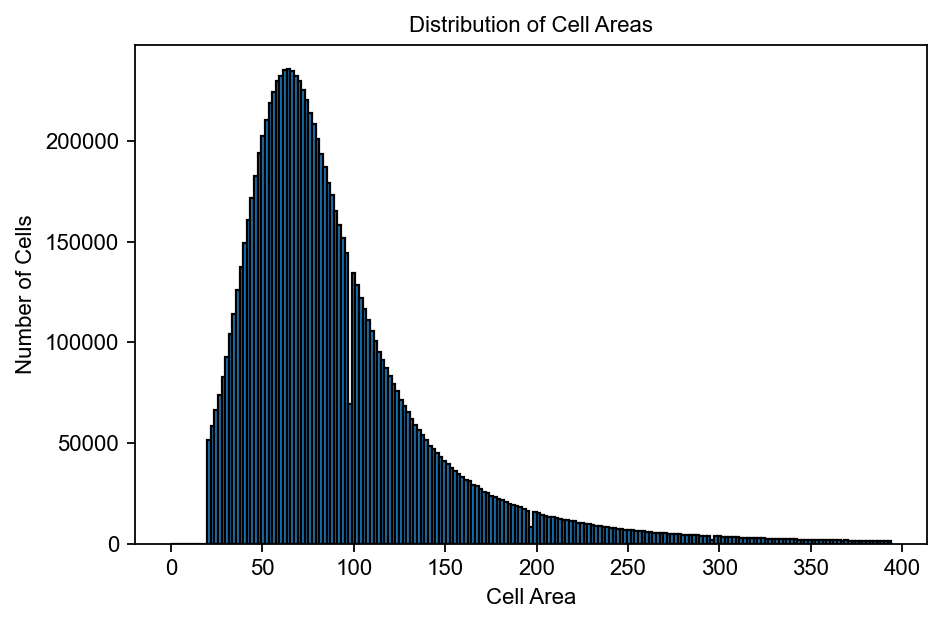


Top 10 cells with highest marker_sum:
  L14_20244: 182.70
  L14_20241: 182.19
  L14_20243: 172.24
  C33_1962: 163.90
  C33_24513: 162.17
  C33_2070: 159.45
  C33_2111: 158.59
  C35_925: 157.93
  C35_23024: 157.57
  C35_1216: 157.45


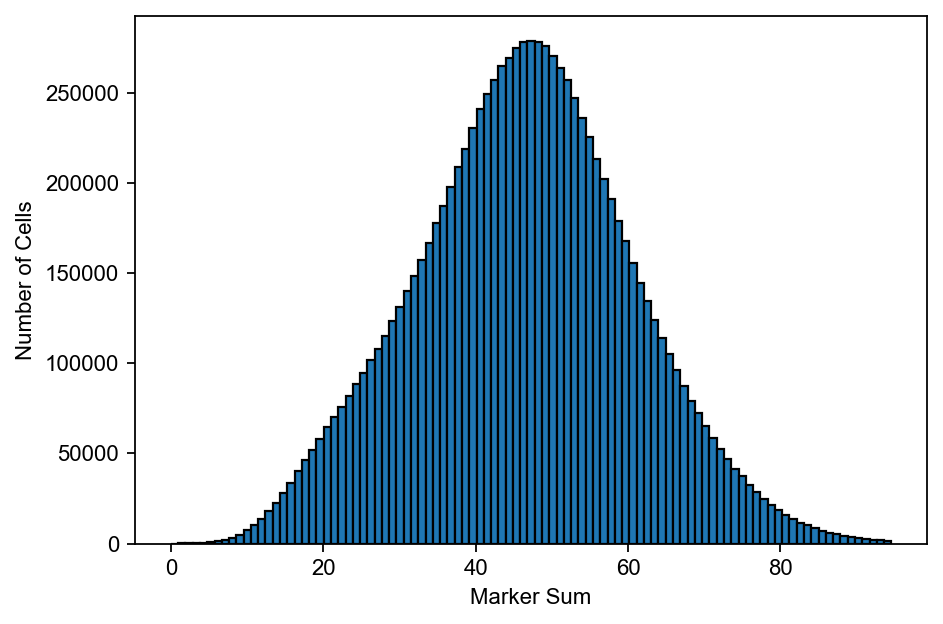

In [2]:
data = assembling.assemble_anndata(base_dir, add_polarity=True)

data = assembling.add_metadata(data, base_dir=base_dir, metadata_files=['CasenumbersStanfordALL.csv','CasenumbersTubingenALL.csv'], merge_on_column="Image")
data = assembling.add_metadata(data, base_dir=base_dir, metadata_files=['zonal_areas_summary.csv'], merge_on_column="Image")

assembling.anndata_qc(data)

data.write('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/data_with_polarity.h5ad')

In [3]:
data = ad.read_h5ad('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/data_with_polarity.h5ad')

data.obs['Casenumber'] = data.obs['Casenumber'].str.upper()
data.obs["TMA"] = data.obs["Image"].str[0]

# Exclude Background and TMA controls
mask = ((data.obs['Zone'] != 'Background') & 
        (~data.obs['Casenumber'].str.contains('TONSIL|LIVER', na=False)))
data = data[mask].copy()

data.obs['Region'] = data.obs['Zone'].str.split("_").str[0]

# Add panel
panel = pd.read_csv(os.path.join(base_dir, "panel.csv"))
data.var['marker'] = panel['marker'].tolist()
data.var['channel_marker'] = panel['name'].tolist()
data.var.index = data.var['marker']
gc.collect()

25039

# Batch correction

In [49]:
# Use arcsinh-transformed signal as input
X_raw = np.arcsinh((data.layers["counts"] * data.layers["polarity"]) - 1 ).astype(np.float32)
batches = data.obs["TMA"].values
markers = data.var_names

corrected = np.zeros_like(X_raw, dtype=np.float32)
unique_batches = np.unique(batches)

nq = 100  # number of quantiles (50–200 is fine)

for i, marker in enumerate(tqdm(markers, desc="Quantile normalizing per marker")):
    x = X_raw[:, i]
    corrected_marker = np.zeros_like(x)
    
    # --- 1. Fit reference distribution (global across all batches) ---
    ref_qt = QuantileTransformer(
        output_distribution="uniform",
        n_quantiles=nq,
        random_state=42,
        subsample=1_000_000
    )
    ref_qt.fit(x.reshape(-1, 1))
    ref_vals = ref_qt.quantiles_.ravel()  # flatten to 1-D
    
    # target quantile grid (0..1)
    q_grid = np.linspace(0, 1, nq)
    
    # --- 2. Align each batch to the reference ---
    for b in unique_batches:
        mask = batches == b
        xb = x[mask]
        
        if xb.size < 10:
            # Skip tiny batches
            corrected_marker[mask] = xb
            continue
        
        qt_batch = QuantileTransformer(
            output_distribution="uniform",
            n_quantiles=min(nq, xb.size),
            random_state=42,
            subsample=min(len(xb), 500_000)
        )
        qt_batch.fit(xb.reshape(-1, 1))
        
        xb_uniform = qt_batch.transform(xb.reshape(-1, 1)).ravel()
        corrected_marker[mask] = np.interp(xb_uniform, q_grid, ref_vals)
    
    corrected[:, i] = corrected_marker

# Save the corrected matrix back into the AnnData object
data.layers["corrected"] = corrected
del corrected
del X_raw

Quantile normalizing per marker: 100%|██████████| 49/49 [02:18<00:00,  2.83s/it]


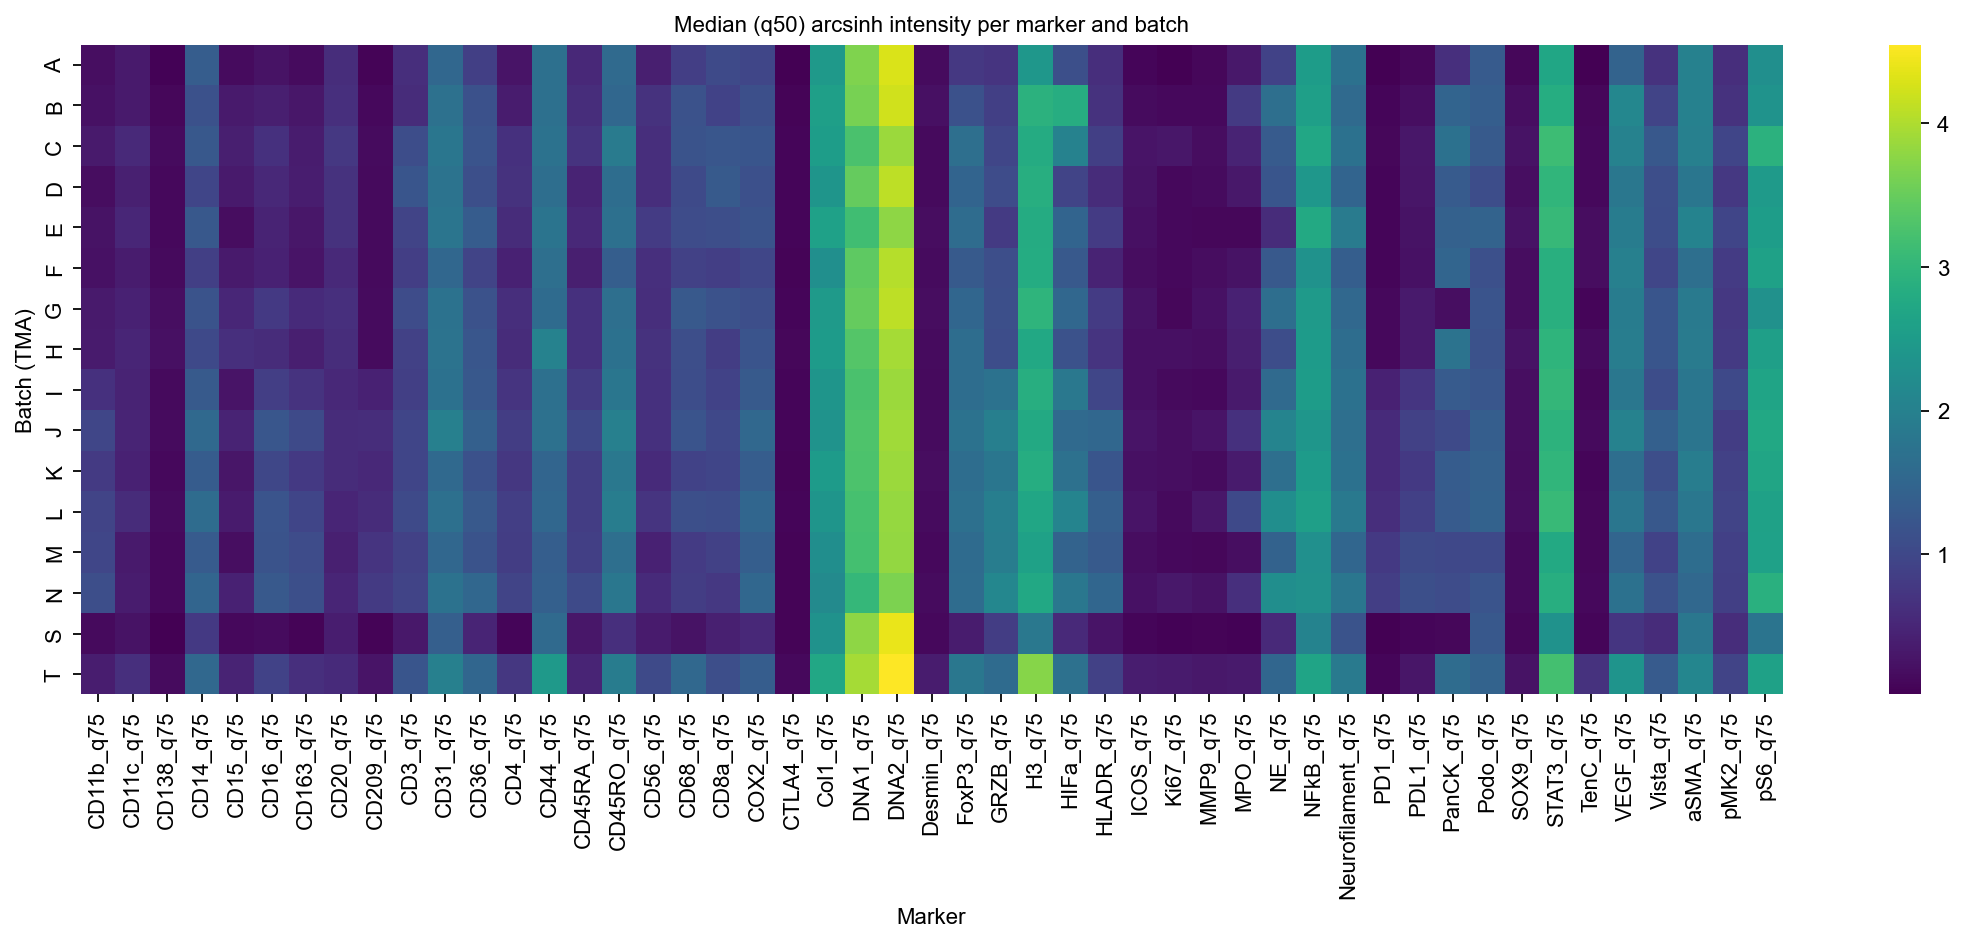

In [5]:
X = pd.DataFrame(
    np.arcsinh(data.layers["counts"]).astype(np.float32),
    columns=data.var_names,
    index=data.obs_names
)

batches = data.obs["TMA"]

# --- 2. Compute quantiles per batch and marker ---
quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]

# Join the batch info
X["TMA"] = batches.values

# Compute quantiles per batch and marker
quantile_df = (
    X.groupby("TMA")
    .quantile(quantiles)
    .reset_index()
)

# The resulting index has two levels: 'TMA' and the quantile level
# We'll pivot to have markers × quantiles per batch
quantile_df = quantile_df.melt(
    id_vars=["TMA", "level_1"],
    var_name="Marker",
    value_name="Intensity"
)
quantile_df["Quantile"] = quantile_df["level_1"].map(lambda q: f"q{int(q*100)}")
quantile_df.drop(columns="level_1", inplace=True)

# --- 3. Optional: Pivot into a wide table for heatmap ---
pivot_df = (
    quantile_df.pivot_table(
        index="TMA",
        columns=["Marker", "Quantile"],
        values="Intensity"
    )
)

# Simplify multiindex columns for visualization
pivot_df.columns = [f"{marker}_{quantile}" for marker, quantile in pivot_df.columns]

# --- 4. Visualize median (q50) intensities per batch ---
median_cols = [c for c in pivot_df.columns if "_q75" in c]
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_df[median_cols], cmap="viridis")
plt.title("Median (q50) arcsinh intensity per marker and batch")
plt.xlabel("Marker")
plt.ylabel("Batch (TMA)")
plt.tight_layout()
plt.show()

In [6]:
counts = np.arcsinh(data.layers["counts"] - 1)
corrected = data.layers["corrected"]

# Difference matrix
diff = corrected - counts  # shape (cells, markers)

# mean absolute change per marker
marker_change = np.mean(np.abs(diff), axis=0)
marker_change = pd.Series(marker_change, index=data.var.index).sort_values(ascending=False)
print("Top markers changed by batch correction:")
print(marker_change.head(20))

Top markers changed by batch correction:
marker
GRZB      0.600127
NE        0.441184
H3        0.430601
FoxP3     0.411056
VEGF      0.389412
HIFa      0.363285
pS6       0.338592
STAT3     0.309158
CD45RO    0.304669
HLADR     0.290709
CD16      0.266530
NFkB      0.263539
COX2      0.263254
PDL1      0.251220
CD14      0.250177
CD44      0.250115
DNA1      0.246043
CD11b     0.244310
DNA2      0.241923
CD163     0.238462
dtype: float32


In [7]:
cell_change = np.sum(np.abs(diff), axis=1)
cell_change = pd.Series(cell_change, index=data.obs.index)
image_change = cell_change.groupby(data.obs["Image"]).mean().sort_values(ascending=False)
print("Images most affected by batch correction:")
print(image_change.head(20))

Images most affected by batch correction:
Image
S25    32.221786
S09    28.994938
S06    28.938499
S05    28.638914
S13    28.417606
S24    28.104034
S07    28.074202
S21    27.496473
S11    27.166334
S19    25.988268
S65    25.978718
S12    25.957516
S08    25.655329
S10    25.591063
S55    24.973875
S14    24.569265
S71    24.351727
S57    24.171780
S31    24.142939
S39    24.085651
dtype: float32


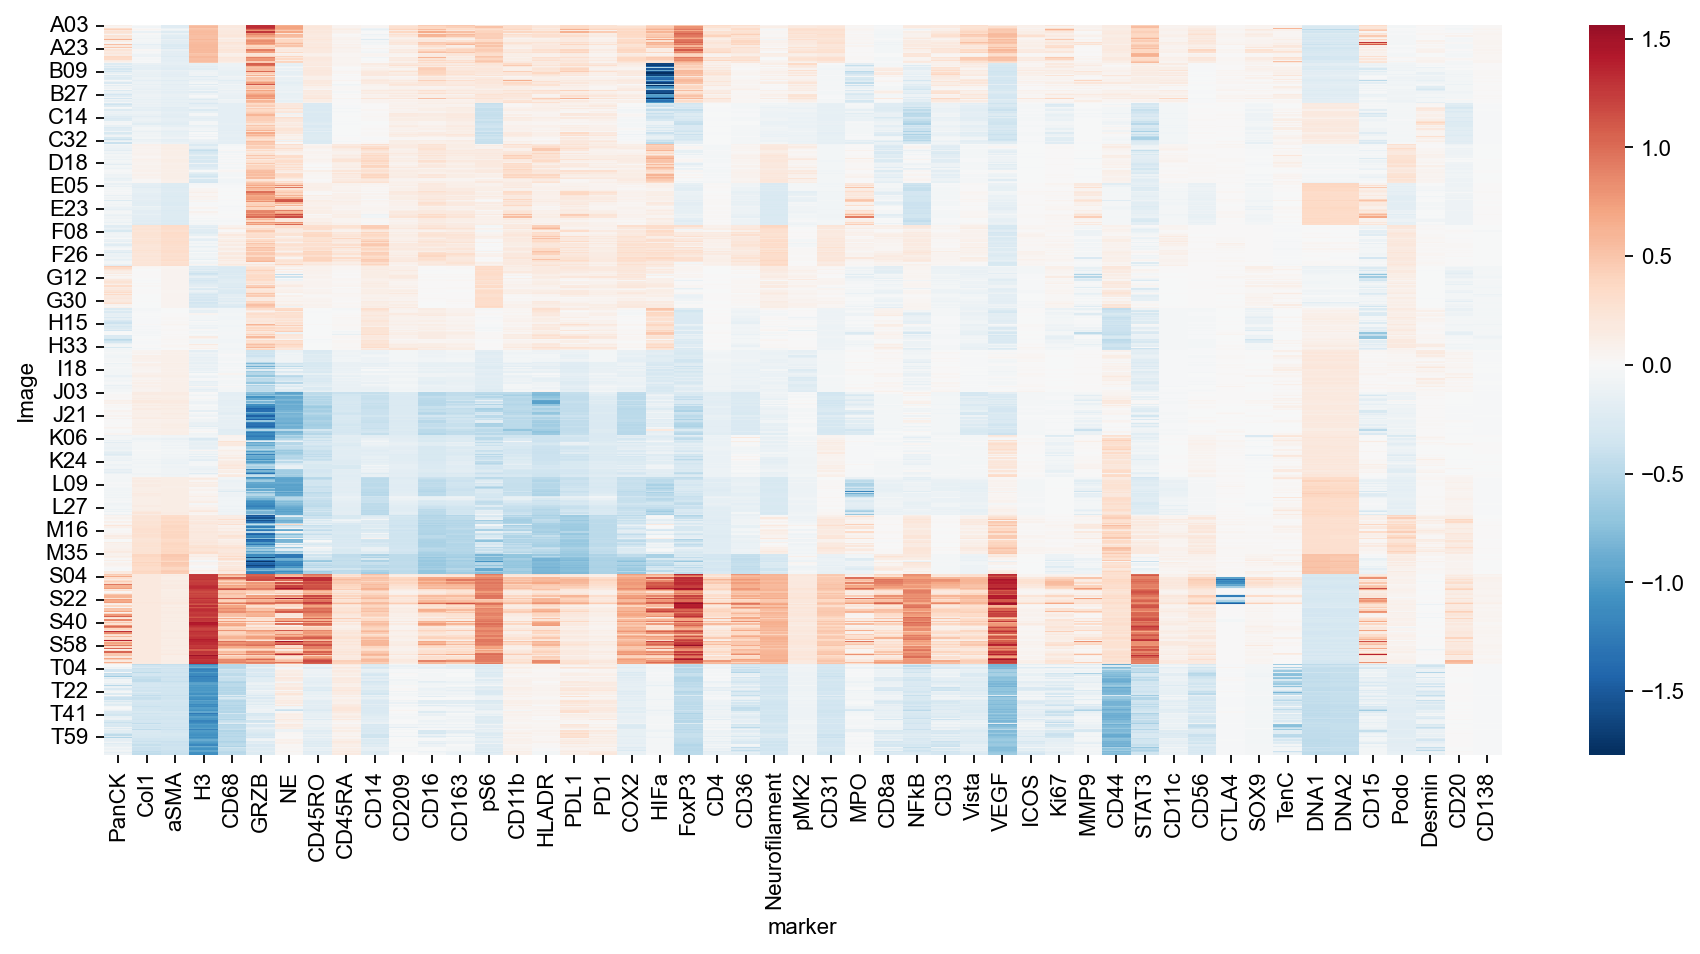

In [8]:
# directional difference
diff = corrected - counts  # shape (cells, markers)
df_diff = pd.DataFrame(diff, index=data.obs.index, columns=data.var.index)

# add Image column for grouping
df_diff["Image"] = data.obs["Image"].values

heatmap_data = df_diff.groupby("Image").mean()
heatmap_data = heatmap_data.astype(float)

plt.figure(figsize=(14,6))
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",        # diverging colormap
    center=0
)
# plt.xlabel("Marker")
# plt.ylabel("Image")
# plt.title("Directional change (corrected - counts) per marker per image")
plt.show()

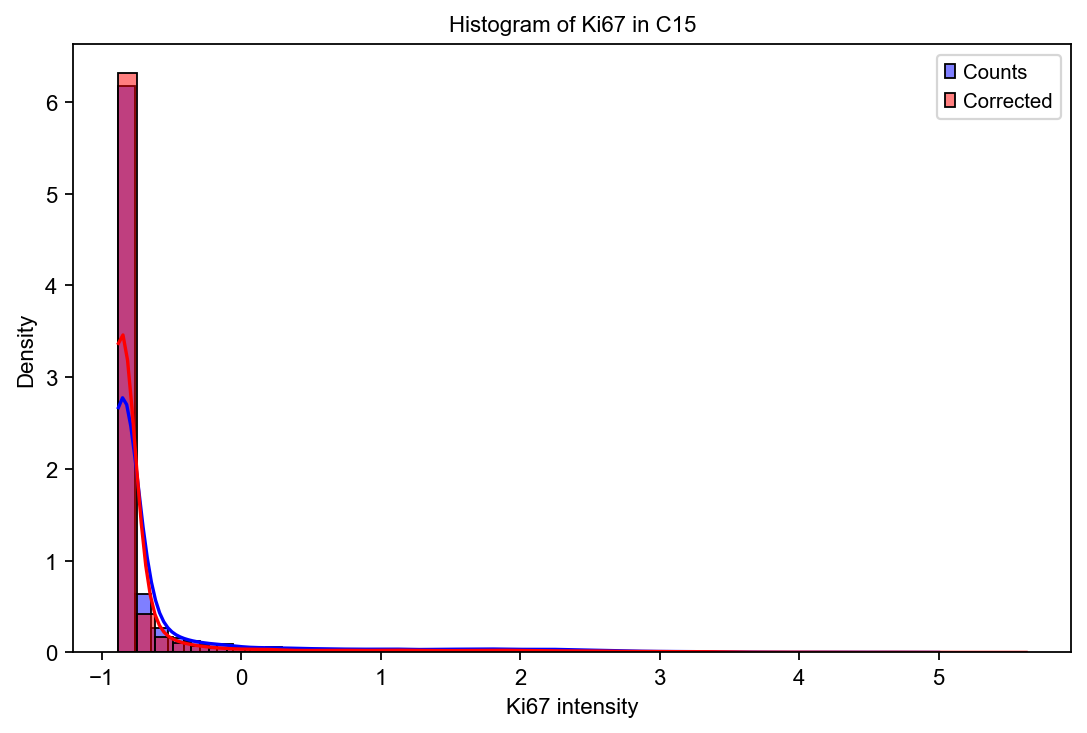

In [30]:
image_name = "C15"       # the image you want
marker = "Ki67"           # the marker you want

# Get cell indices for this image
idx = data.obs["Image"] == image_name

# Extract counts and corrected values for this marker
values_counts = np.arcsinh(data.layers["counts"][idx, data.var.index.get_loc(marker)] - 1)
values_corrected = data.layers["corrected"][idx, data.var.index.get_loc(marker)]

plt.figure(figsize=(8,5))
sns.histplot(values_counts, color="blue", label="Counts", kde=True, stat="density", bins=50, alpha=0.5)
sns.histplot(values_corrected, color="red", label="Corrected", kde=True, stat="density", bins=50, alpha=0.5)

plt.xlabel(f"{marker} intensity")
plt.ylabel("Density")
plt.title(f"Histogram of {marker} in {image_name}")
plt.legend()
plt.show()

# Phenotyping

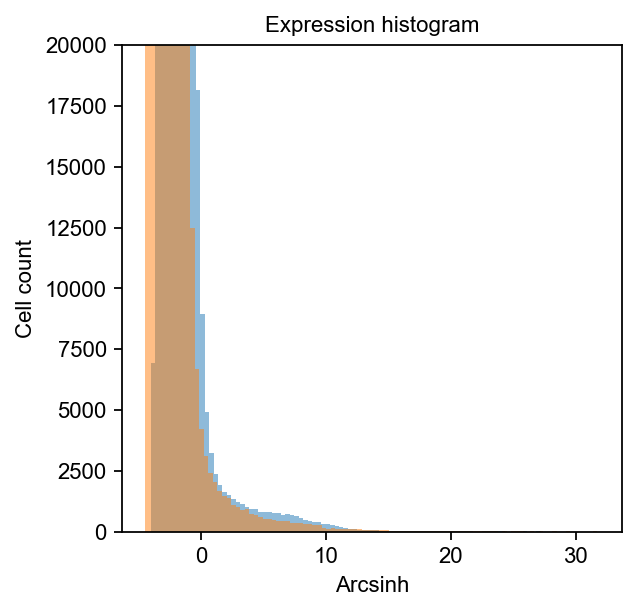

In [57]:
cd68_idx = data.var.index.get_loc("CD20")
mask = data.obs['Region'] == "Tumor"
cd68_vals = np.arcsinh(data.layers['counts'][:, cd68_idx] - 1)[mask]
cd68_vals_c = data.layers['corrected'][:, cd68_idx][mask]

plt.hist(cd68_vals / cd68_vals.std(), bins=100, alpha=0.5)
plt.hist(cd68_vals_c / cd68_vals_c.std(), bins=100, alpha=0.5)
plt.ylim(0, 20_000)
plt.xlabel("Arcsinh")
plt.ylabel("Cell count")
plt.title("Expression histogram")
plt.show()

## Tumor subsetting

Setting: 

lr=0.0005, prior_std=0.3, max_epochs=400, patience=8, polarity=False, 113 epochs, 

Results: 

TumorNonproliferating    0.413678
TumorSOX9+               0.121837
TumorpMK2+               0.116865
CD8Tcells                0.110369
Granulocytes             0.072233
TumorKi67+               0.064336
TumorKi67+SOX9+          0.054136
CD4Tcells                0.030836
Bcells                   0.005253

In [58]:
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_tumor_new.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="Image",
                      filter="Region",
                      filter_for="Tumor",
                      unassigned_label="TumorNonproliferating",
                      phenotype_level="Celltype",
                      prior_std=0.3,
                      polarity=False)

Subsetted AnnData to 2708206 cells.
Filtered for Tumor from Region
Running SCYAN on 2708206 cells...


[INFO] (scyan.model) Initialized Scyan model with N=2708206 cells, P=16 populations and M=19 markers.
   ├── Covariates: Image
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       Image
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.3
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 158 K  | train
-----------------------------------------------
158 K     Trainable params
0         Non-trainable params
158 K     Total params
0.635     Total estimated model params size (MB)
243       Modules in train mode
0         Modu

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/331 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Celltype' (subset):
 Celltype
TumorNonproliferating    0.436829
TumorSOX9+               0.183332
CD8Tcells                0.090002
Granulocytes             0.063114
TumorKi67+SOX9+          0.055831
TumorKi67+               0.055429
Monocytes                0.034851
CD4Tcells                0.025107
TumorpMK2+               0.021310
Macrophages              0.020070
Capillary                0.005839
Bcells                   0.004896
SM                       0.002297
NaN                      0.000704
NKcells                  0.000297
Nerve                    0.000079
Arteriole                0.000011
Name: proportion, dtype: float64

Absolute counts by 'Celltype' (subset):
 Celltype
TumorNonproliferating    1183024
TumorSOX9+                496502
CD8Tcells                 243745
Granulocytes              170927
TumorKi67+SOX9+           151202
TumorKi67+                150113
Monocytes                  94383
CD4Tcells                  67994
TumorpM

AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype', 'Subtype', 'Distance_to_tumor'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'counts', 'polarity', 'corrected'

## Stroma subsetting

Settings: 

lr=0.0005, prior_std=0.4, max_epochs=400, patience=8, polarity=False, 131 epochs, 

Results:
Other                    0.187321
CD8Tcells                0.159827
CD4Tcells                0.123115
Granulocytes             0.089797
Capillary                0.087337
Bcells                   0.066582
Macrophages              0.055866
Arteriole                0.053131
Monocytes                0.046908
TumorNonproliferating    0.041357
FibroblastsTenC+         0.030246
SM                       0.029278
Lymphatics               0.026701
Nerve                    0.001860

In [59]:
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_stroma.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="TMA",
                      filter="Region",
                      filter_for="Stroma",
                      unassigned_label="Other",
                      phenotype_level="Celltype",
                      prior_std=0.4,
                      polarity=True)

Subsetted AnnData to 5620148 cells.
Filtered for Stroma from Region
Running SCYAN on 5620148 cells...


[INFO] (scyan.model) Initialized Scyan model with N=5620148 cells, P=15 populations and M=20 markers.
   ├── Covariates: TMA
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       TMA
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.4
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 35.9 K | train
-----------------------------------------------
35.9 K    Trainable params
0         Non-trainable params
35.9 K    Total params
0.144     Total estimated model params size (MB)
243       Modules in train mode
0         Modules 

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/687 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Celltype' (subset):
 Celltype
Other                    0.209253
CD8Tcells                0.145001
CD4Tcells                0.098410
Capillary                0.097016
TumorNonproliferating    0.089510
Bcells                   0.083800
Granulocytes             0.079185
Arteriole                0.071431
Macrophages              0.049399
Monocytes                0.036565
Lymphatics               0.025785
FibroblastsTenC+         0.007165
SM                       0.005350
Nerve                    0.002004
NaN                      0.000117
NKcells                  0.000010
Name: proportion, dtype: float64

Absolute counts by 'Celltype' (subset):
 Celltype
Other                    1176032
CD8Tcells                 814927
CD4Tcells                 553077
Capillary                 545244
TumorNonproliferating     503058
Bcells                    470970
Granulocytes              445033
Arteriole                 401450
Macrophages               277628
Monocyte

AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype', 'Subtype', 'Distance_to_tumor'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'counts', 'polarity', 'corrected'

## Muscle subsetting

Settings: 

lr=0.0005, prior_std=0.3, max_epochs=400, patience=8, polarity=True, 60 epoches

Results:

SM              0.848713
Capillary       0.074307
Granulocytes    0.025103
Macrophages     0.014928
Bcells          0.010080
Monocytes       0.007407

In [66]:
import importlib
importlib.reload(phenotyping)
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_muscle_new.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="Image", 
                      filter="Region",
                      filter_for="Muscle",
                      unassigned_label="Other",
                      phenotype_level="Celltype",
                      prior_std=0.26,
                      polarity=True)

Subsetted AnnData to 728480 cells.
Filtered for Muscle from Region
Running SCYAN on 728480 cells...


[INFO] (scyan.model) Initialized Scyan model with N=728480 cells, P=14 populations and M=17 markers.
   ├── Covariates: Image
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       Image
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.26
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 145 K  | train
-----------------------------------------------
145 K     Trainable params
0         Non-trainable params
145 K     Total params
0.582     Total estimated model params size (MB)
243       Modules in train mode
0         Modu

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/89 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Celltype' (subset):
 Celltype
SM                       0.788280
Capillary                0.075310
CD8Tcells                0.051738
Arteriole                0.030329
Granulocytes             0.027066
Bcells                   0.014698
TumorNonproliferating    0.008040
Monocytes                0.002767
Lymphatics               0.000863
Macrophages              0.000697
FibroblastsTenC+         0.000122
NaN                      0.000070
CD4Tcells                0.000010
NKcells                  0.000007
Nerve                    0.000003
Name: proportion, dtype: float64

Absolute counts by 'Celltype' (subset):
 Celltype
SM                       574246
Capillary                 54862
CD8Tcells                 37690
Arteriole                 22094
Granulocytes              19717
Bcells                    10707
TumorNonproliferating      5857
Monocytes                  2016
Lymphatics                  629
Macrophages                 508
FibroblastsTenC+   

AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype', 'Subtype', 'Distance_to_tumor'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'counts', 'polarity', 'corrected'

In [26]:
for col in data.obs.select_dtypes(include=["datetime64[ns]"]).columns:
    data.obs[col] = data.obs[col].dt.strftime("%Y-%m-%d")
data.write('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/11222025_annotdata.h5ad')

## CD4 T cell subsetting

Settings: prior_std=0.4, lr=0.00001, polarity=True, max_epochs=400, patience=8, 150 epochs

Results: 

CD4Tmemory    0.751599
CD4Tfh        0.109102
CD4Tnaive     0.100423
CD4Tregs      0.038858

In [2]:
data = ad.read_h5ad('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/11222025_annotdata.h5ad')

In [68]:
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_CD4Tcells.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="TMA", 
                      filter="Celltype",
                      filter_for="CD4Tcells",
                      unassigned_label="CD4Tmemory",
                      phenotype_level="Subtype",
                      prior_std=0.28,
                      polarity=True)

Subsetted AnnData to 621078 cells.
Filtered for CD4Tcells from Celltype
Running SCYAN on 621078 cells...


[INFO] (scyan.model) Initialized Scyan model with N=621078 cells, P=4 populations and M=5 markers.
   ├── Covariates: TMA
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       TMA
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.28
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 29.0 K | train
-----------------------------------------------
29.0 K    Trainable params
0         Non-trainable params
29.0 K    Total params
0.116     Total estimated model params size (MB)
243       Modules in train mode
0         Modules in

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/76 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Subtype' (subset):
 Subtype
CD4Tmemory    0.778923
CD4Tnaive     0.084613
CD4Tfh        0.077177
CD4Tregs      0.059287
Name: proportion, dtype: float64

Absolute counts by 'Subtype' (subset):
 Subtype
CD4Tmemory    483772
CD4Tnaive      52551
CD4Tfh         47933
CD4Tregs       36822
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype', 'Subtype', 'Distance_to_tumor'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'counts', 'polarity', 'corrected'

## CD8 T cell subsetting

Settings: lr=0.0005, prior_std=0.3, polarity=True, 32 epochs

Results:

CD8Tmemory     0.481928
CD8Teff        0.342798
CD8Tnaive      0.141382
CD8Ttrmlike    0.033469

In [72]:
import importlib
importlib.reload(phenotyping)
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_CD8Tcells.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="Image", 
                      filter="Celltype",
                      filter_for="CD8Tcells",
                      unassigned_label="CD8Tmemory",
                      phenotype_level="Subtype",
                      prior_std=0.3,
                      polarity=True)

Subsetted AnnData to 1096362 cells.
Filtered for CD8Tcells from Celltype
Running SCYAN on 1096362 cells...


[INFO] (scyan.model) Initialized Scyan model with N=1096362 cells, P=4 populations and M=5 markers.
   ├── Covariates: Image
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       Image
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.3
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 153 K  | train
-----------------------------------------------
153 K     Trainable params
0         Non-trainable params
153 K     Total params
0.614     Total estimated model params size (MB)
243       Modules in train mode
0         Module

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/134 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Subtype' (subset):
 Subtype
CD8Tmemory     0.503789
CD8Teff        0.368920
CD8Tnaive      0.099065
CD8Ttrmlike    0.027964
NaN            0.000262
Name: proportion, dtype: float64

Absolute counts by 'Subtype' (subset):
 Subtype
CD8Tmemory     552335
CD8Teff        404470
CD8Tnaive      108611
CD8Ttrmlike     30659
NaN               287
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype', 'Subtype', 'Distance_to_tumor'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'counts', 'polarity', 'corrected'

## MacroMono subsetting

In [73]:
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_MacroMono.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="TMA", 
                      filter="Celltype",
                      filter_for=["Macrophages", "Monocytes"],
                      unassigned_label="M1Macro",
                      phenotype_level="Subtype",
                      prior_std=0.5,
                      polarity=True)

Subsetted AnnData to 634391 cells.
Filtered for ['Macrophages', 'Monocytes'] from Celltype
Running SCYAN on 634391 cells...


[INFO] (scyan.model) Initialized Scyan model with N=634391 cells, P=5 populations and M=7 markers.
   ├── Covariates: TMA
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       TMA
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.5
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 29.9 K | train
-----------------------------------------------
29.9 K    Trainable params
0         Non-trainable params
29.9 K    Total params
0.120     Total estimated model params size (MB)
243       Modules in train mode
0         Modules in 

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/78 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Subtype' (subset):
 Subtype
M1Macro          0.666376
M2Macro          0.212571
M2MacroCD209+    0.066733
DCs              0.033569
Monocytes        0.020743
NaN              0.000008
Name: proportion, dtype: float64

Absolute counts by 'Subtype' (subset):
 Subtype
M1Macro          422743
M2Macro          134853
M2MacroCD209+     42335
DCs               21296
Monocytes         13159
NaN                   5
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype', 'Subtype', 'Distance_to_tumor'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'counts', 'polarity', 'corrected'

In [74]:
# Ensure both are categorical
data.obs["Celltype"] = data.obs["Celltype"].astype("category")
data.obs["Subtype"] = data.obs["Subtype"].astype("category")

# Add any missing categories from Celltype into Subtype
missing_cats = [cat for cat in data.obs["Celltype"].cat.categories
                if cat not in data.obs["Subtype"].cat.categories]
if missing_cats:
    data.obs["Subtype"] = data.obs["Subtype"].cat.add_categories(missing_cats)

# Fill only missing values in Subtype with string values from Celltype
mask = data.obs["Subtype"].isna()
data.obs.loc[mask, "Subtype"] = data.obs.loc[mask, "Celltype"].astype(str)

# Clean unused categories
data.obs["Subtype"] = data.obs["Subtype"].astype("category")
data.obs["Subtype"] = data.obs["Subtype"].cat.remove_unused_categories()

In [75]:
data.obs

,Object,Image,Area,Centroid-0,Centroid-1,Axis_major_length,Axis_minor_length,Eccentricity,Orientation,Zone,...,Blocknumber,Stromacore,Stromaborder,Tumorborder,Tumorcore,TMA,Region,Celltype,Subtype,Distance_to_tumor
UniqueCellID,,,,,,,,,,,,,,,,,,,,,
C13_1,1,C13,34,1.411765,753.000000,9.893551,4.351351,0.898087,1.570796,Stroma_Stromacore,...,1,1135542,271427,440708,592595,C,Stroma,TumorNonproliferating,TumorNonproliferating,-219.161595
C13_2,2,C13,23,1.217391,765.130435,7.305178,4.069709,0.830446,1.526359,Stroma_Stromacore,...,1,1135542,271427,440708,592595,C,Stroma,Other,Other,-231.011586
C13_3,3,C13,32,1.375000,813.000000,9.380832,4.444097,0.880663,1.570796,Stroma_Stromacore,...,1,1135542,271427,440708,592595,C,Stroma,Capillary,Capillary,-277.840825
C13_4,4,C13,22,1.454545,856.590909,6.109224,4.782858,0.622159,1.566220,Stroma_Stromacore,...,1,1135542,271427,440708,592595,C,Stroma,Capillary,Capillary,-313.442961
C13_5,5,C13,27,1.444444,978.111111,7.811726,4.378867,0.828120,1.504521,Stroma_Stromacore,...,1,1135542,271427,440708,592595,C,Stroma,Bcells,Bcells,-376.297197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N14_16417,16417,N14,346,1743.187861,680.075145,33.832336,14.232223,0.907214,0.784300,Muscle_Stromacore,...,9,2379699,121723,47016,575,N,Muscle,CD8Tcells,CD8Teff,-173.023270
N14_16418,16418,N14,80,1756.250000,816.662500,12.457964,9.131081,0.680281,-0.755987,Muscle_Stromacore,...,9,2379699,121723,47016,575,N,Muscle,SM,SM,-262.491179
N14_16419,16419,N14,62,1766.032258,700.774194,11.158972,7.504818,0.740064,1.229022,Muscle_Stromacore,...,9,2379699,121723,47016,575,N,Muscle,SM,M1Macro,-201.908928


In [76]:
data.write('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/12132025_annotdata_withpolarity.h5ad')

In [6]:
data = ad.read_h5ad('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/12132025_annotdata_withpolarity.h5ad')

# Distance to the tumorborder

In [35]:
data = tissuezones3.calculate_distance_to_tumor(base_dir, data, columnname='Distance_to_tumor', overwrite=False)

Calculating distance to tumor: 100%|██████████| 572/572 [28:49<00:00,  3.02s/it]


# Phenotype plotting

<Axes: ylabel='count'>

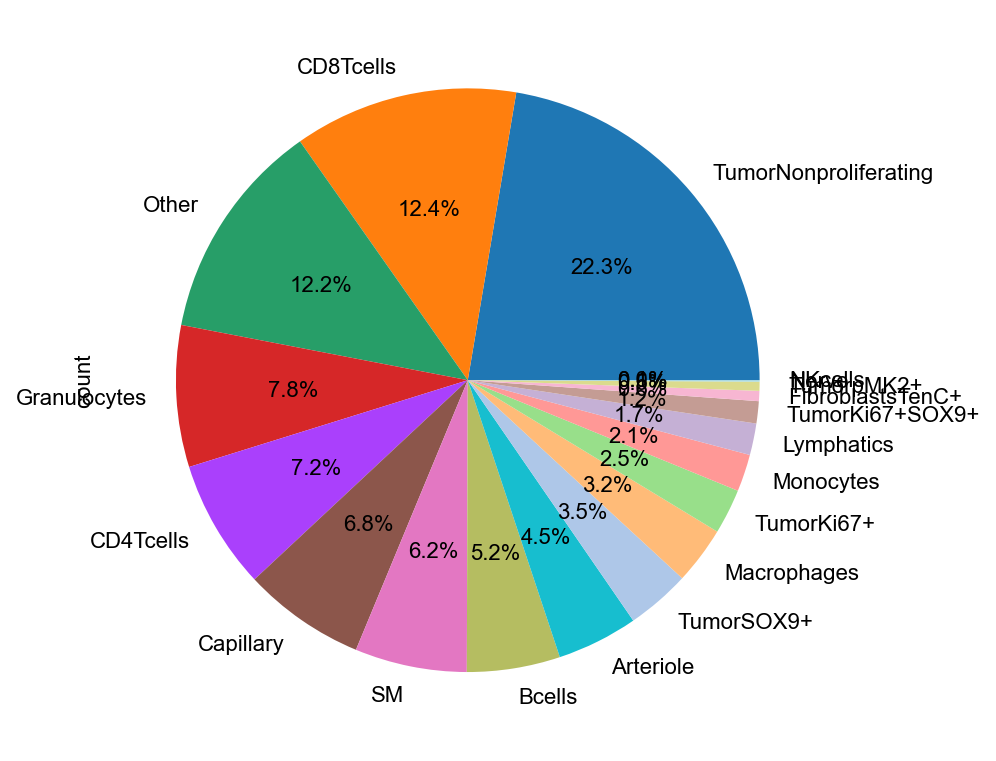

In [38]:
# Quick counts per cell type
data.obs['Celltype'].value_counts()
data.obs['Celltype'].value_counts(normalize=True) * 100
data.obs['Celltype'].value_counts().plot.pie(autopct="%.1f%%", figsize=(6,6))

In [ ]:
#plotting.mask_colored_by_category(data, image_name = "A17", base_dir= base_dir, category_column = "Celltype", output_dir = "tmp")
#plotting.create_multicolor_image(data, channels=["PanCK", "Desmin", "DNA1"], image_name = 'A17', base_dir = base_dir, contrast_bounds=(1,90))
#plotting.mask_colored_by_continuous(data, image_name = "A17", base_dir = base_dir, value_column="CD8a", clip_percentiles=(1,99))

In [18]:
custom_pal = glasbey.create_block_palette(
    [1, 2, 2, 2, 1, 3, 4],
    lightness_bounds=(10, 90),
    chroma_bounds=(10, 90))
custom_cmap = mcolors.ListedColormap(list(custom_pal), name="custom_glasbey")

In [ ]:
counts = data.obs.groupby(["Subtype", "Region", "Image"]).size().reset_index(name="count")
max_images = counts.loc[counts.groupby(["Subtype", "Region"])["count"].idxmax()]

In [ ]:
counts = data.obs.groupby(["Subtype", "Region", "Image"]).size().reset_index(name="count")
total_cells_per_image = data.obs.groupby(["Region", "Image"]).size().reset_index(name="total_count")
counts = counts.merge(total_cells_per_image, on=["Region", "Image"])
counts["rel_prop"] = counts["count"] / counts["total_count"]
idx = counts.groupby(["Subtype", "Region"])["count"].idxmax()
idx = idx.dropna()
max_images = counts.loc[idx]

In [ ]:
channel_colors = {
    "PanCK": "#2A5674",    # deep orange
    "Desmin": "#68ABB8",   # crimson
}

plotting.create_multicolor_image(data, channels=["PanCK", "Desmin"], 
                                 image_name = 'S42', channel_colors=channel_colors, 
                                 base_dir = base_dir, contrast_bounds=(50,70),
                                 output_dir = "tmp",
                                 scale_bar=100)

[✓] Saved TIFF to /Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis/tmp/T19_colored_by_CD8a.tiff


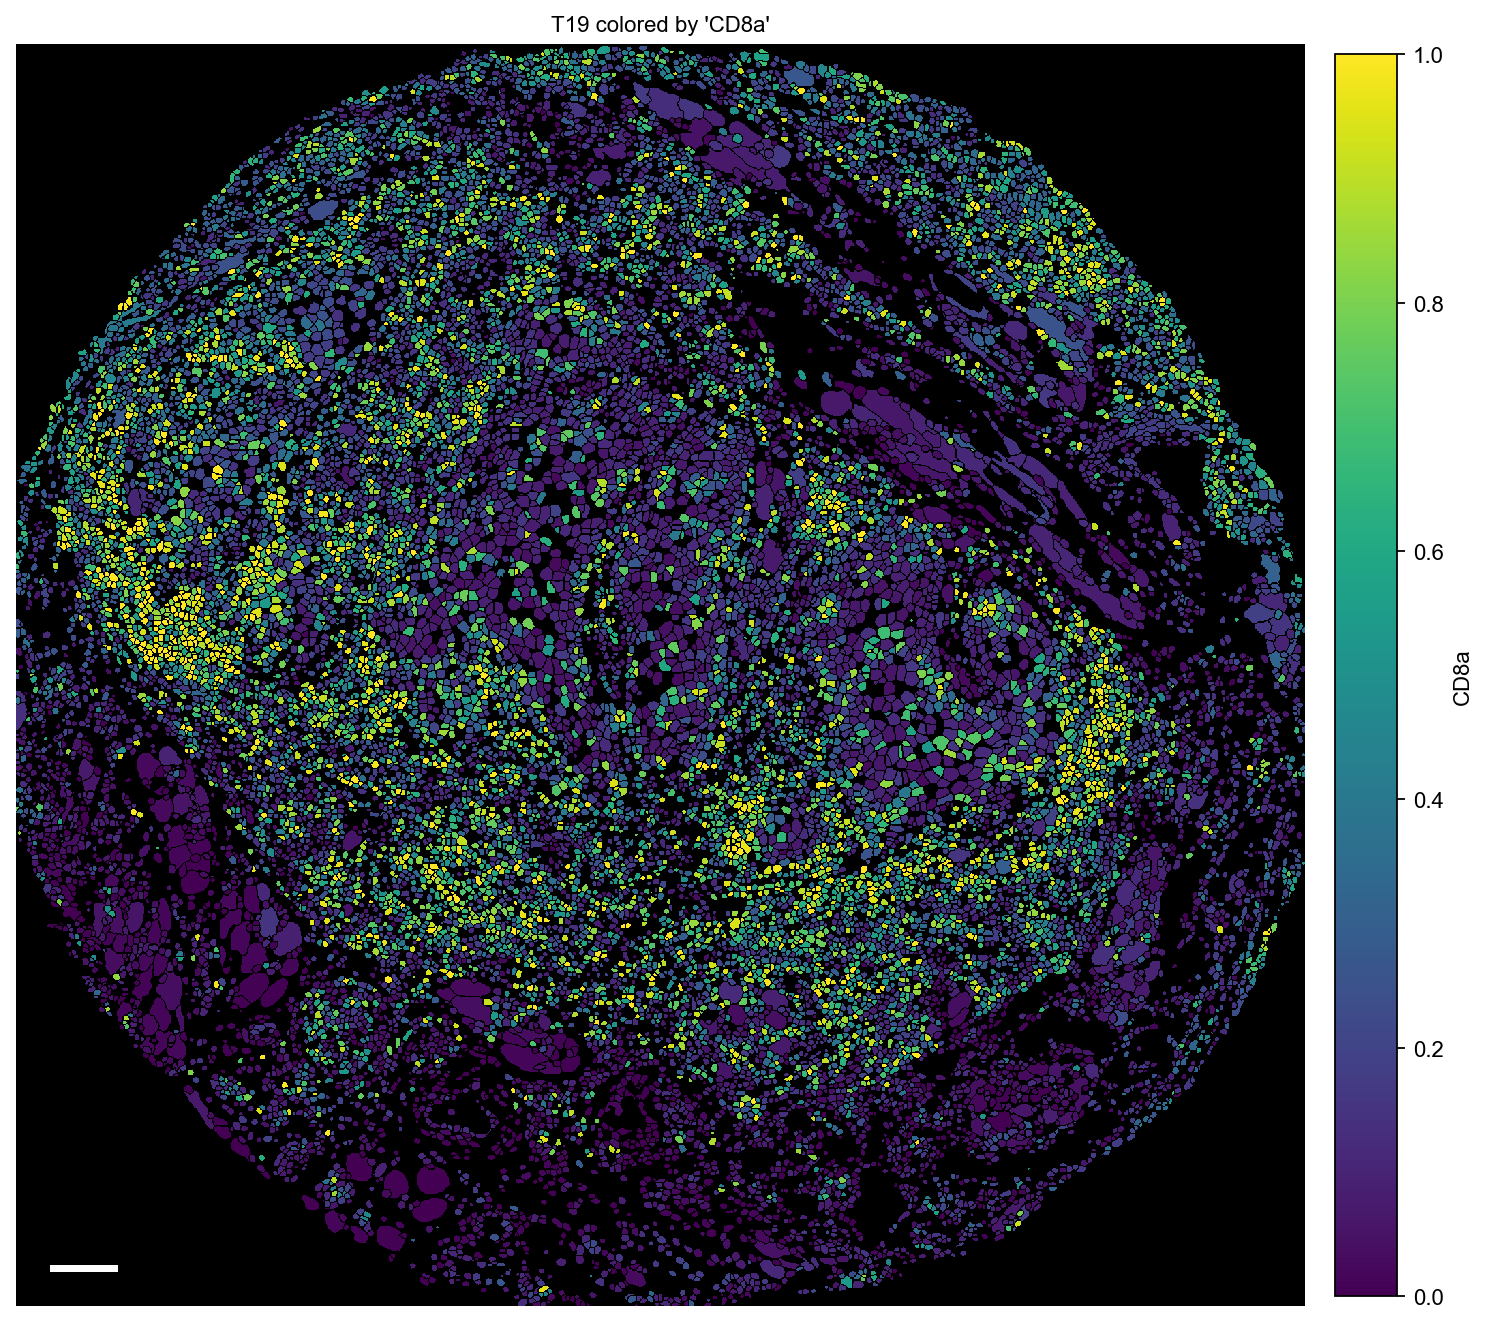

In [77]:
import importlib
importlib.reload(plotting)
plotting.mask_colored_by_continuous(
    data, 
    image_name="T19", 
    base_dir=base_dir, 
    value_column="CD8a", 
    output_dir="tmp",
    scale_bar=100
)

[✓] Saved TIFF to /Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis/tmp/T19_colored_by_CD8a.tiff


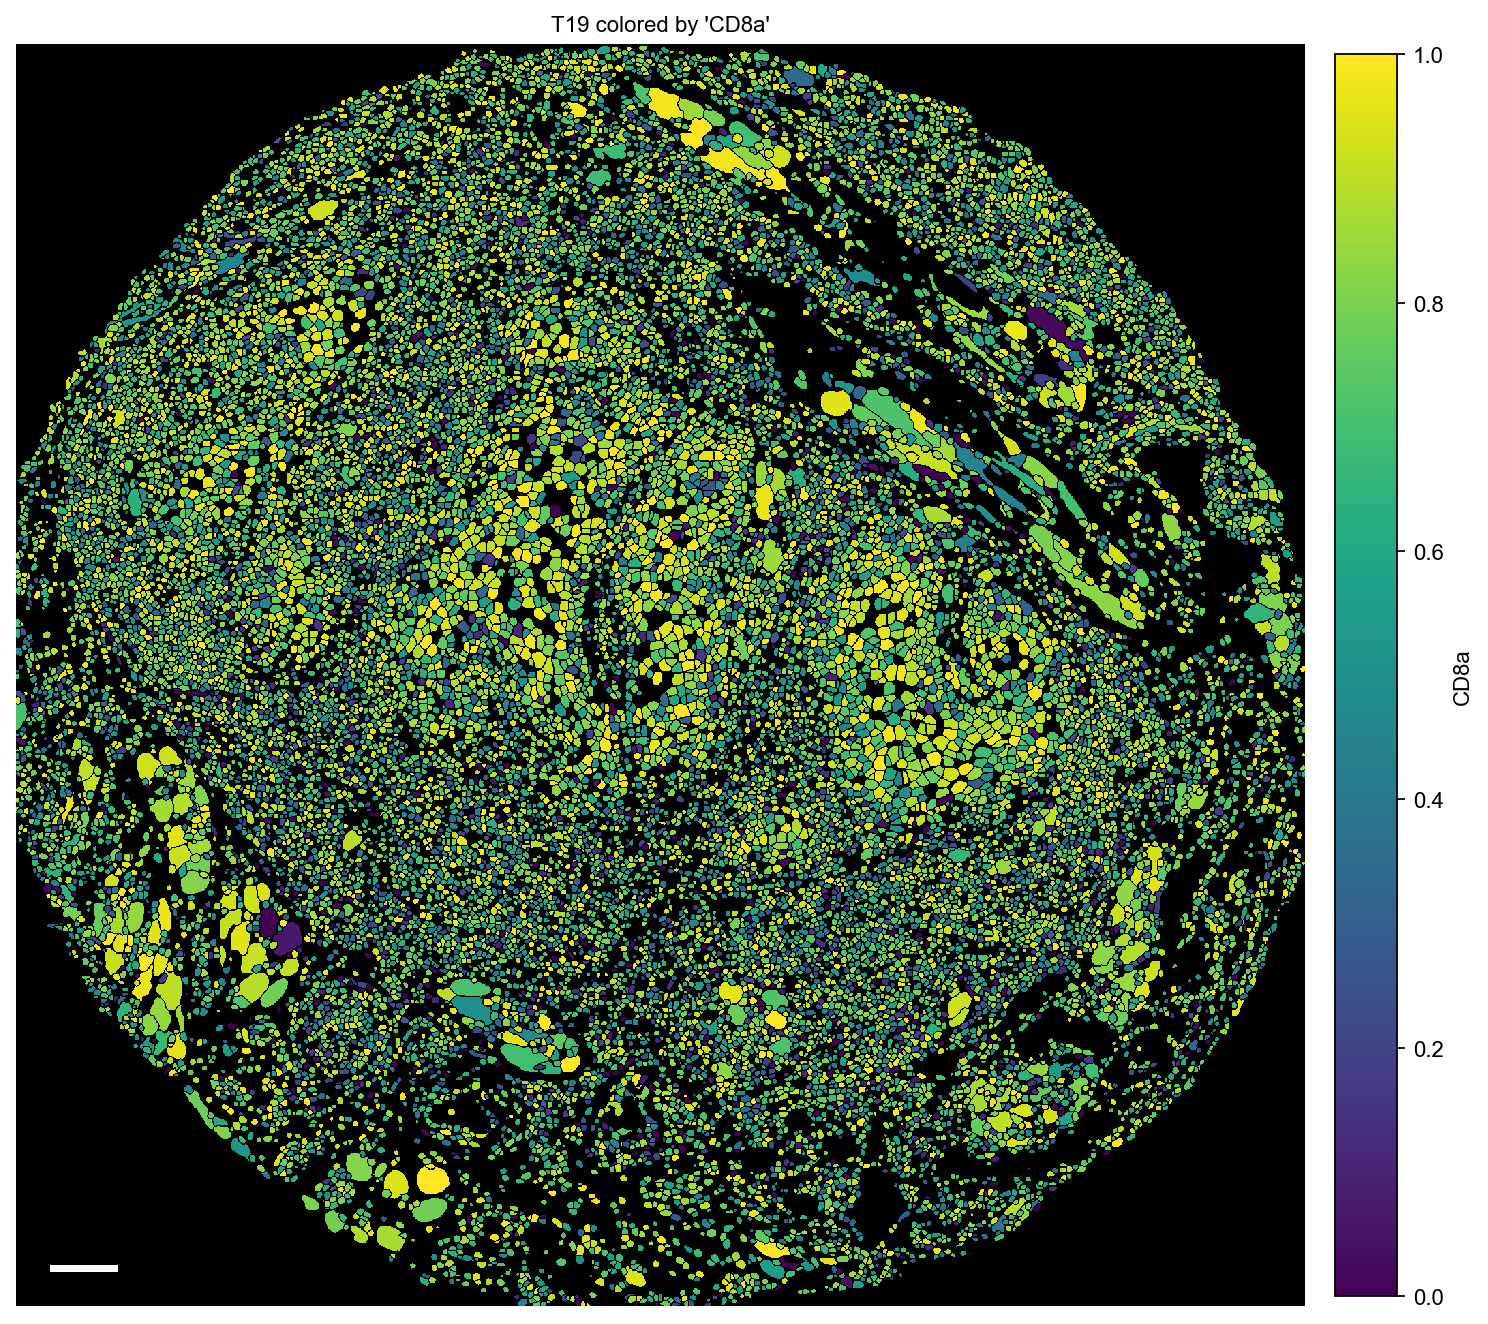

In [41]:
import importlib
importlib.reload(plotting)
plotting.mask_colored_by_continuous(
    data, 
    image_name="T19", 
    base_dir=base_dir, 
    value_column="CD8a", 
    output_dir="tmp",
    scale_bar=100
)

[✓] Saved TIFF to /Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis/tmp/E11_colored_by_Celltype.tiff


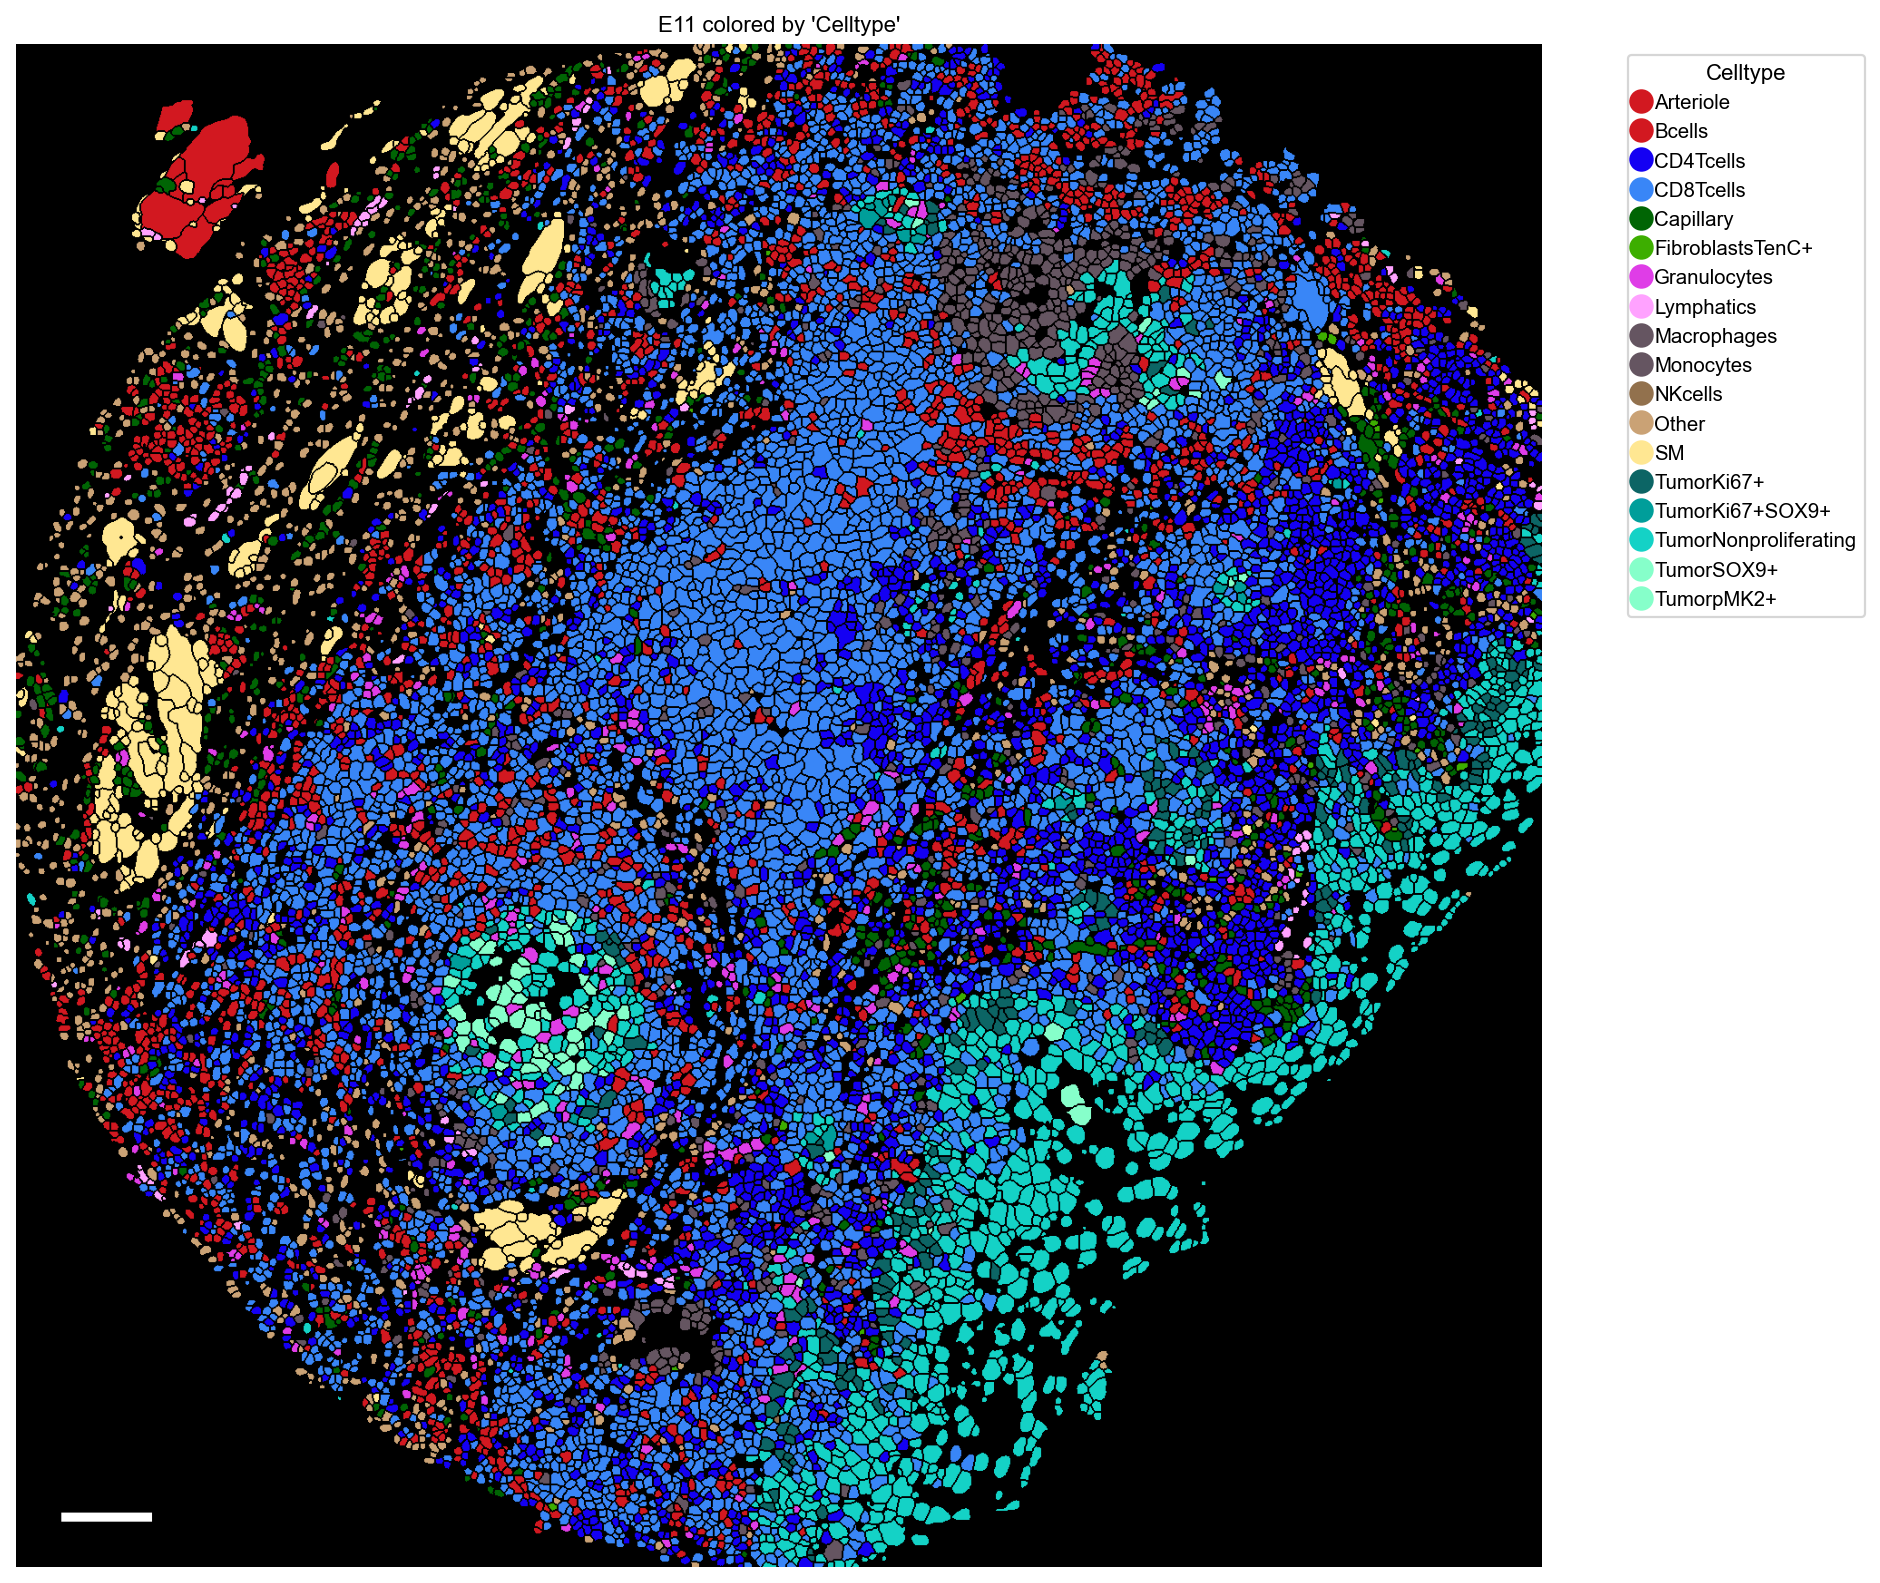

In [ ]:
plotting.mask_colored_by_category(
    data, 
    image_name="E11", 
    base_dir=base_dir, 
    category_column="Celltype", 
    output_dir="tmp",
    custom_palette=custom_cmap,
    scale_bar=100
)

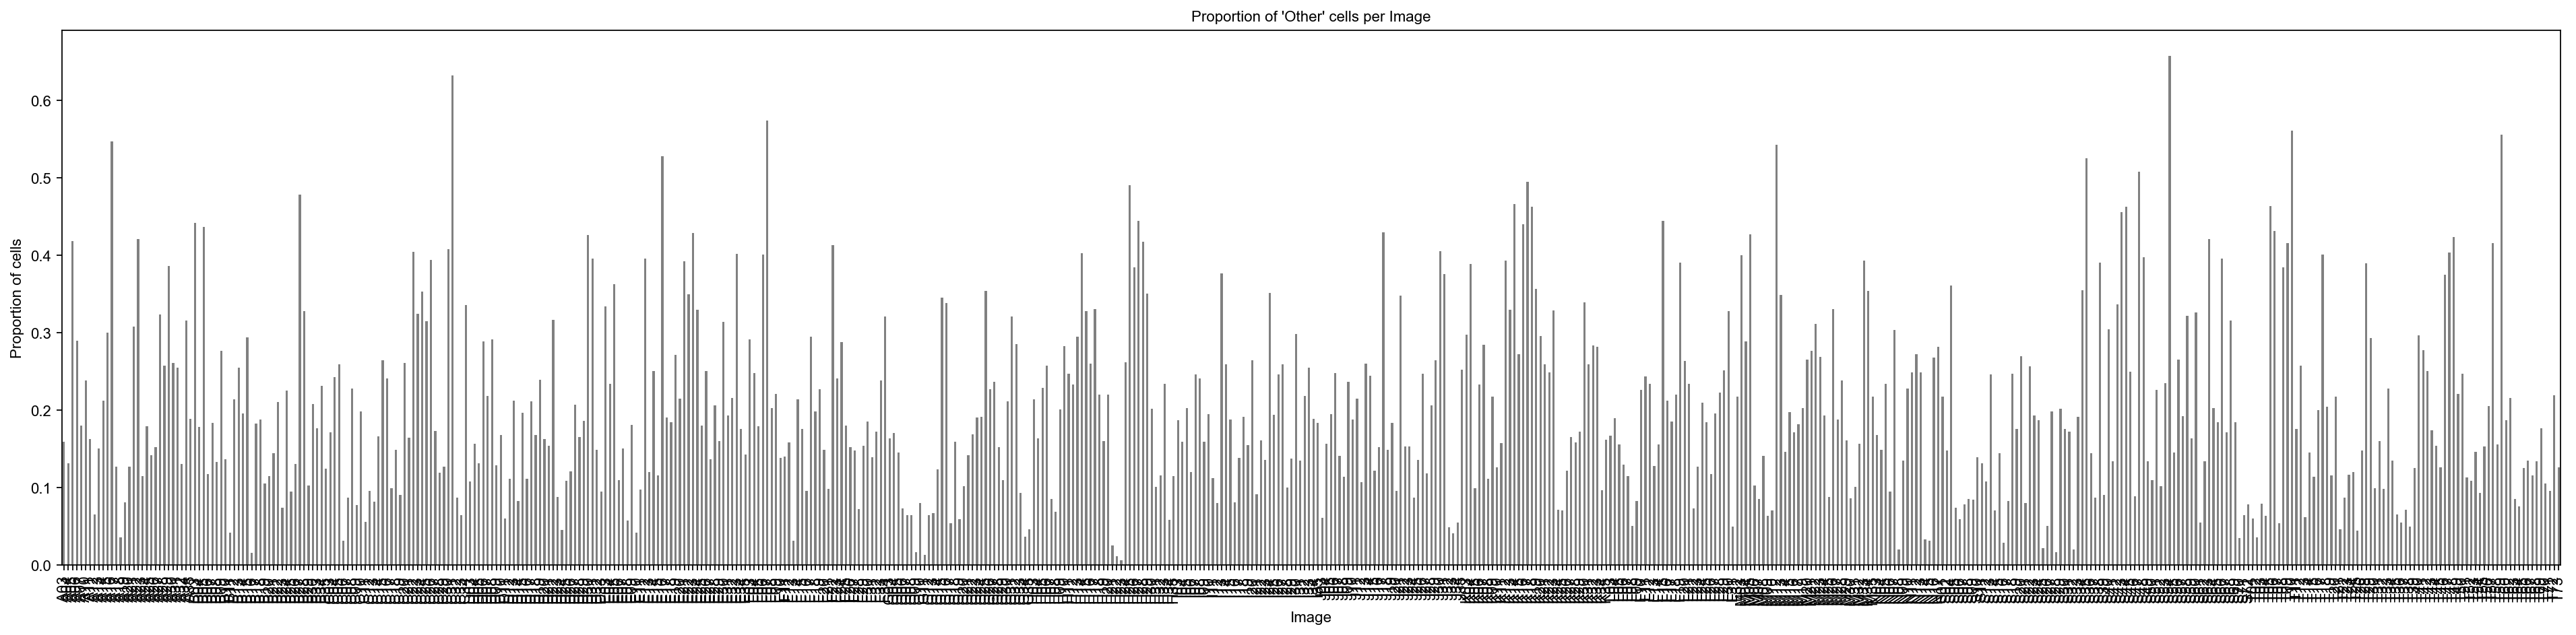

In [83]:
# Filter only "Other"
counts = data.obs.groupby(["Image", "Subtype"]).size().reset_index(name="Count")
counts["Freq"] = counts.groupby("Image")["Count"].transform(lambda x: x / x.sum())

other_counts = counts[counts["Subtype"] == "TumorNonproliferating"]

# Pivot to wide format (one column = Other)
other_pivot = other_counts.pivot(index="Image", columns="Subtype", values="Freq").fillna(0)

# Barplot (not really stacked since only one category, but uniform style)
other_pivot.plot(
    kind="bar", stacked=True, figsize=(24,6), color="gray"
)

plt.ylabel("Proportion of cells")
plt.xticks(rotation=90)
plt.title("Proportion of 'Other' cells per Image")
plt.legend().remove()  # legend not needed for single category
plt.tight_layout()
plt.show()

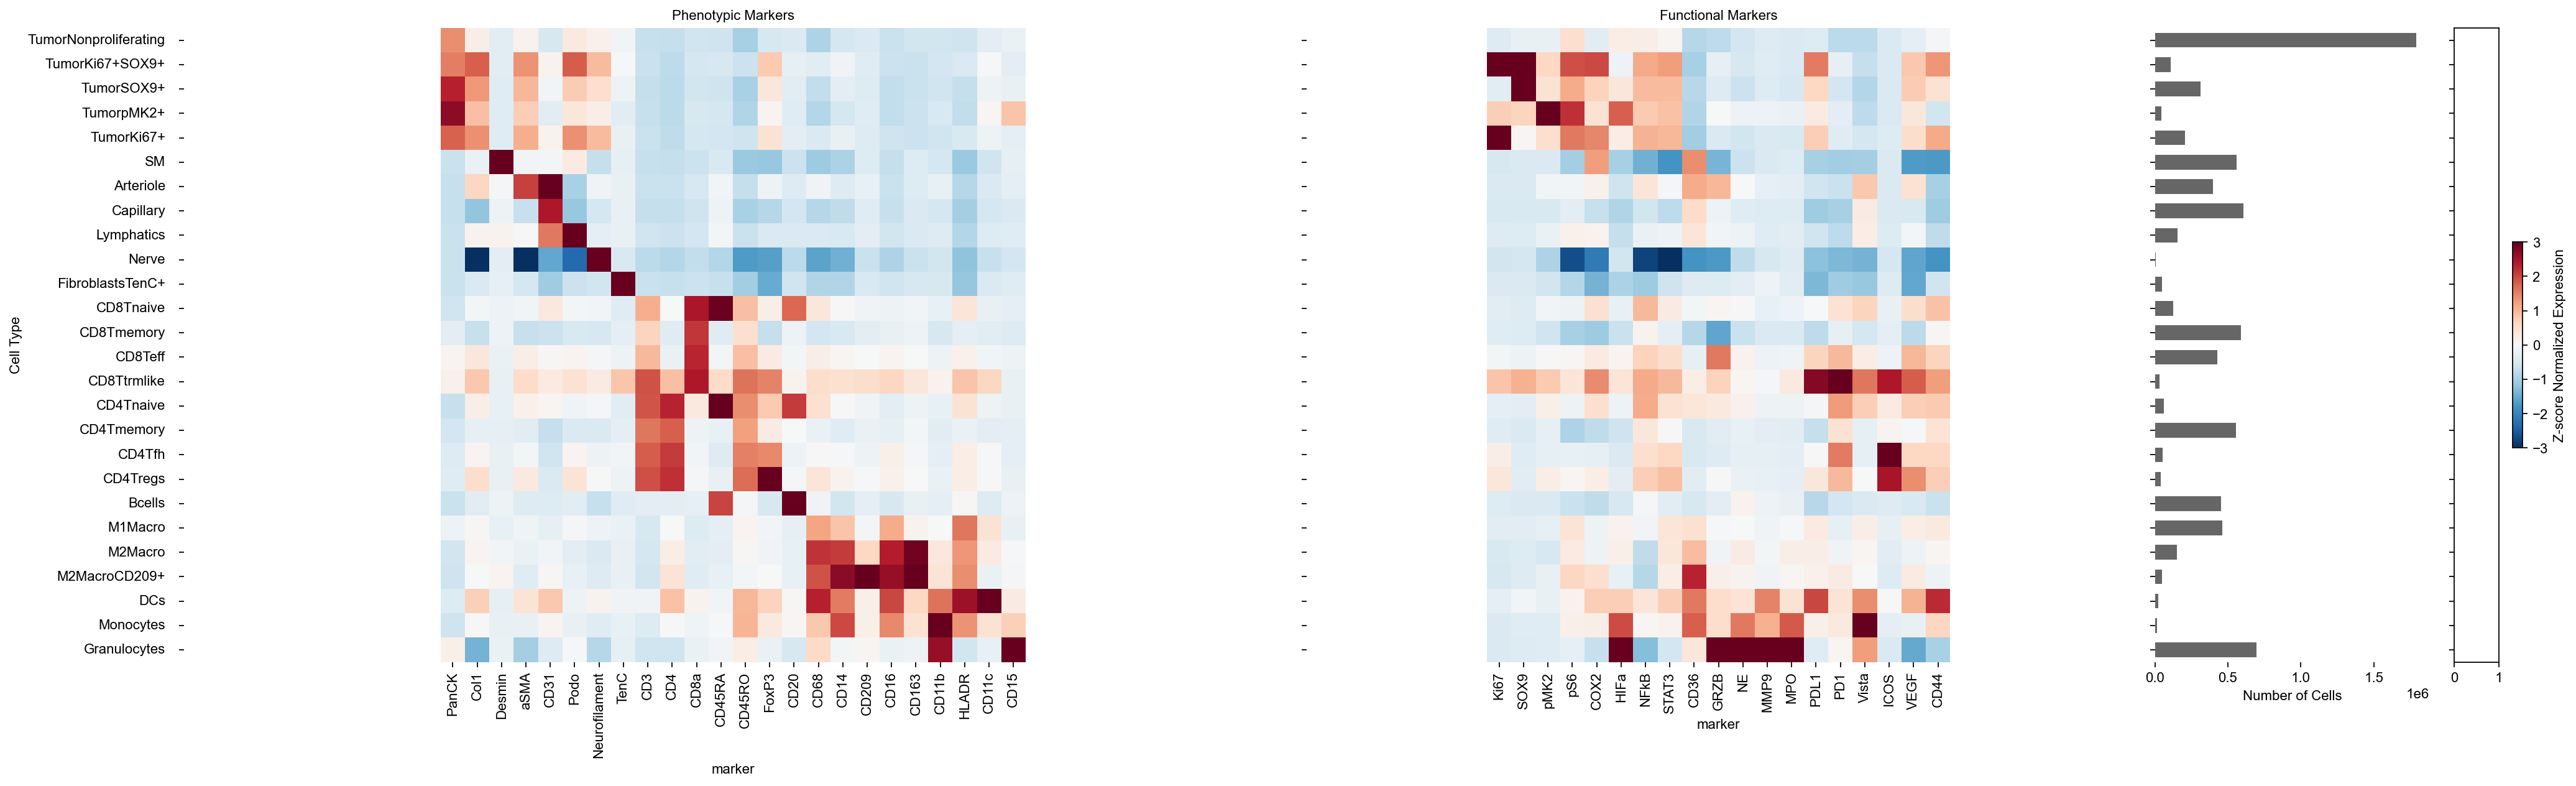

In [84]:
def plot_complex_heatmap(adata, group_variable, phenotypic_markers, functional_markers, desired_order=None):
    # Convert expression data to DataFrame
    exprs_data = pd.DataFrame(adata.layers['corrected'], columns=adata.var.index)
    exprs_data['Cluster'] = adata.obs[group_variable].values

    # Group by cluster and calculate mean expression
    mean_exprs = exprs_data.groupby('Cluster').mean()

    # Normalize expression per marker (Z-score)
    mean_exprs = (mean_exprs - mean_exprs.mean()) / mean_exprs.std()
    if desired_order:
        present_order = [ct for ct in desired_order if ct in mean_exprs.index]
        mean_exprs = mean_exprs.loc[present_order]

    # Extract cell counts per cluster
    cell_counts = exprs_data['Cluster'].value_counts().sort_index()
    cell_counts = cell_counts.reindex(mean_exprs.index).fillna(0)

    # Create a DataFrame to store phenotypic and functional markers separately
    mean_exprs_pheno = mean_exprs[phenotypic_markers]
    mean_exprs_func = mean_exprs[functional_markers]

    combined_data = pd.concat([mean_exprs_pheno, mean_exprs_func], axis=1)
    combined_data = combined_data.apply(pd.to_numeric, errors='raise')
    vmin = -3 #combined_data.min().min()
    vmax = 3 #combined_data.max().max()

    # Set up figure with gridspec for more control over layout
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(26, 8), sharey=True, gridspec_kw={'width_ratios': [8, 6, 2, 0.5]})

    # Create the heatmap for phenotypic markers
    sns.heatmap(mean_exprs_pheno, cmap="RdBu_r", center=0, ax=ax1, #RdGy_r
                yticklabels=True, vmin=vmin, vmax=vmax, cbar=False, xticklabels=True)
    ax1.set_title("Phenotypic Markers")
    ax1.set_ylabel("Cell Type")
    ax1.set_aspect('equal', adjustable='datalim')  # Set aspect ratio to auto to avoid vertical misalignment
    ax1.yaxis.set_ticks_position('left')  # Ensure y-axis ticks are on the left
    ax1.set_yticks(np.arange(len(mean_exprs_pheno)) + 0.5)
    ax1.set_yticklabels(mean_exprs_pheno.index)
    ax1.tick_params(axis='y', pad=10)  # Add padding for y-tick labels

    # Create the heatmap for functional markers
    sns.heatmap(mean_exprs_func, cmap="RdBu_r", center=0, ax=ax2,
                yticklabels=True, vmin=vmin, vmax=vmax, cbar=False, xticklabels=True)
    ax2.set_title("Functional Markers")
    ax2.set_ylabel("")
    ax2.set_aspect('equal', adjustable='datalim') 

    # Create a vertical bar graph for cell counts in the third panel
    ax3.barh(y=np.arange(len(mean_exprs)) + 0.5, width=cell_counts.values, color='black', alpha=0.6, height=0.6)  # Adjust bar width here
    ax3.set_yticks(np.arange(len(mean_exprs_func)) + 0.5)
    ax3.set_yticklabels(mean_exprs_func.index)
    ax3.set_xlabel("Number of Cells")
    #ax3.invert_yaxis()  # Ensure bar chart y-axis is in the same order as heatmap

    # Remove the box around the bar graph
    for spine in ax3.spines.values():
        spine.set_color('none')

    
    # Titles and layout adjustments
    
    # Create a dummy mappable with the same color mapping
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
    sm.set_array([])  # Needed for the colorbar to work
    plt.subplots_adjust(right=0.85) 
    # Add horizontal colorbar below all axes
    cbar = fig.colorbar(sm, ax=  ax4, orientation='vertical', pad=0.2, aspect=20)
    cbar.set_label("Z-score Normalized Expression")
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, "tmp", f"complex_heatmap.pdf"), bbox_inches='tight')
    plt.show()



# Define marker groups
phenotypic_markers = ["PanCK", 
                      "Col1", "Desmin", "aSMA", "CD31", "Podo",  "Neurofilament", "TenC",
                      "CD3", "CD4", "CD8a", "CD45RA", "CD45RO", "FoxP3", "CD20", 
                      "CD68",  "CD14", "CD209", "CD16", "CD163", "CD11b", "HLADR", "CD11c", "CD15"]
functional_markers = ["Ki67", "SOX9", "pMK2", "pS6", "COX2", "HIFa", "NFkB", "STAT3", "CD36",
                      "GRZB", "NE", "MMP9", "MPO", "PDL1", "PD1", "Vista", "ICOS", "VEGF", "CD44"]

# Define the desired order of cell types
desired_order = ['TumorNonproliferating', 'TumorKi67+SOX9+', 'TumorSOX9+', 'TumorpMK2+', 'TumorKi67+',
                 'SM', 'Artery', 'Arteriole', 'Capillary', 'Lymphatics', 'Nerve', 'FibroblastsTenC+',
                 'CD8Tnaive', 'CD8Tmemory', 'CD8Teff', 'CD8Ttrmlike',
                 'CD4Tnaive', 'CD4Tmemory', 'CD4Tfh', 'CD4Tregs',
                 'Bcells',
                 'M1Macro', 'M2Macro', 'M2MacroCD209+', 'DCs', 'Monocytes', 'Granulocytes',]

# Convert the 'subcelltype' column into a categorical type with the defined order
#data.obs["Subtype"] = pd.Categorical(data.obs["Subtype"], categories=desired_order, ordered=True)

plot_complex_heatmap(data, "Subtype", phenotypic_markers, functional_markers, desired_order=desired_order)

Scaling data...
Training SOM grid=(10, 10)...
Meta-clustering into 20 clusters...
Done. Total time: 123.46 sec


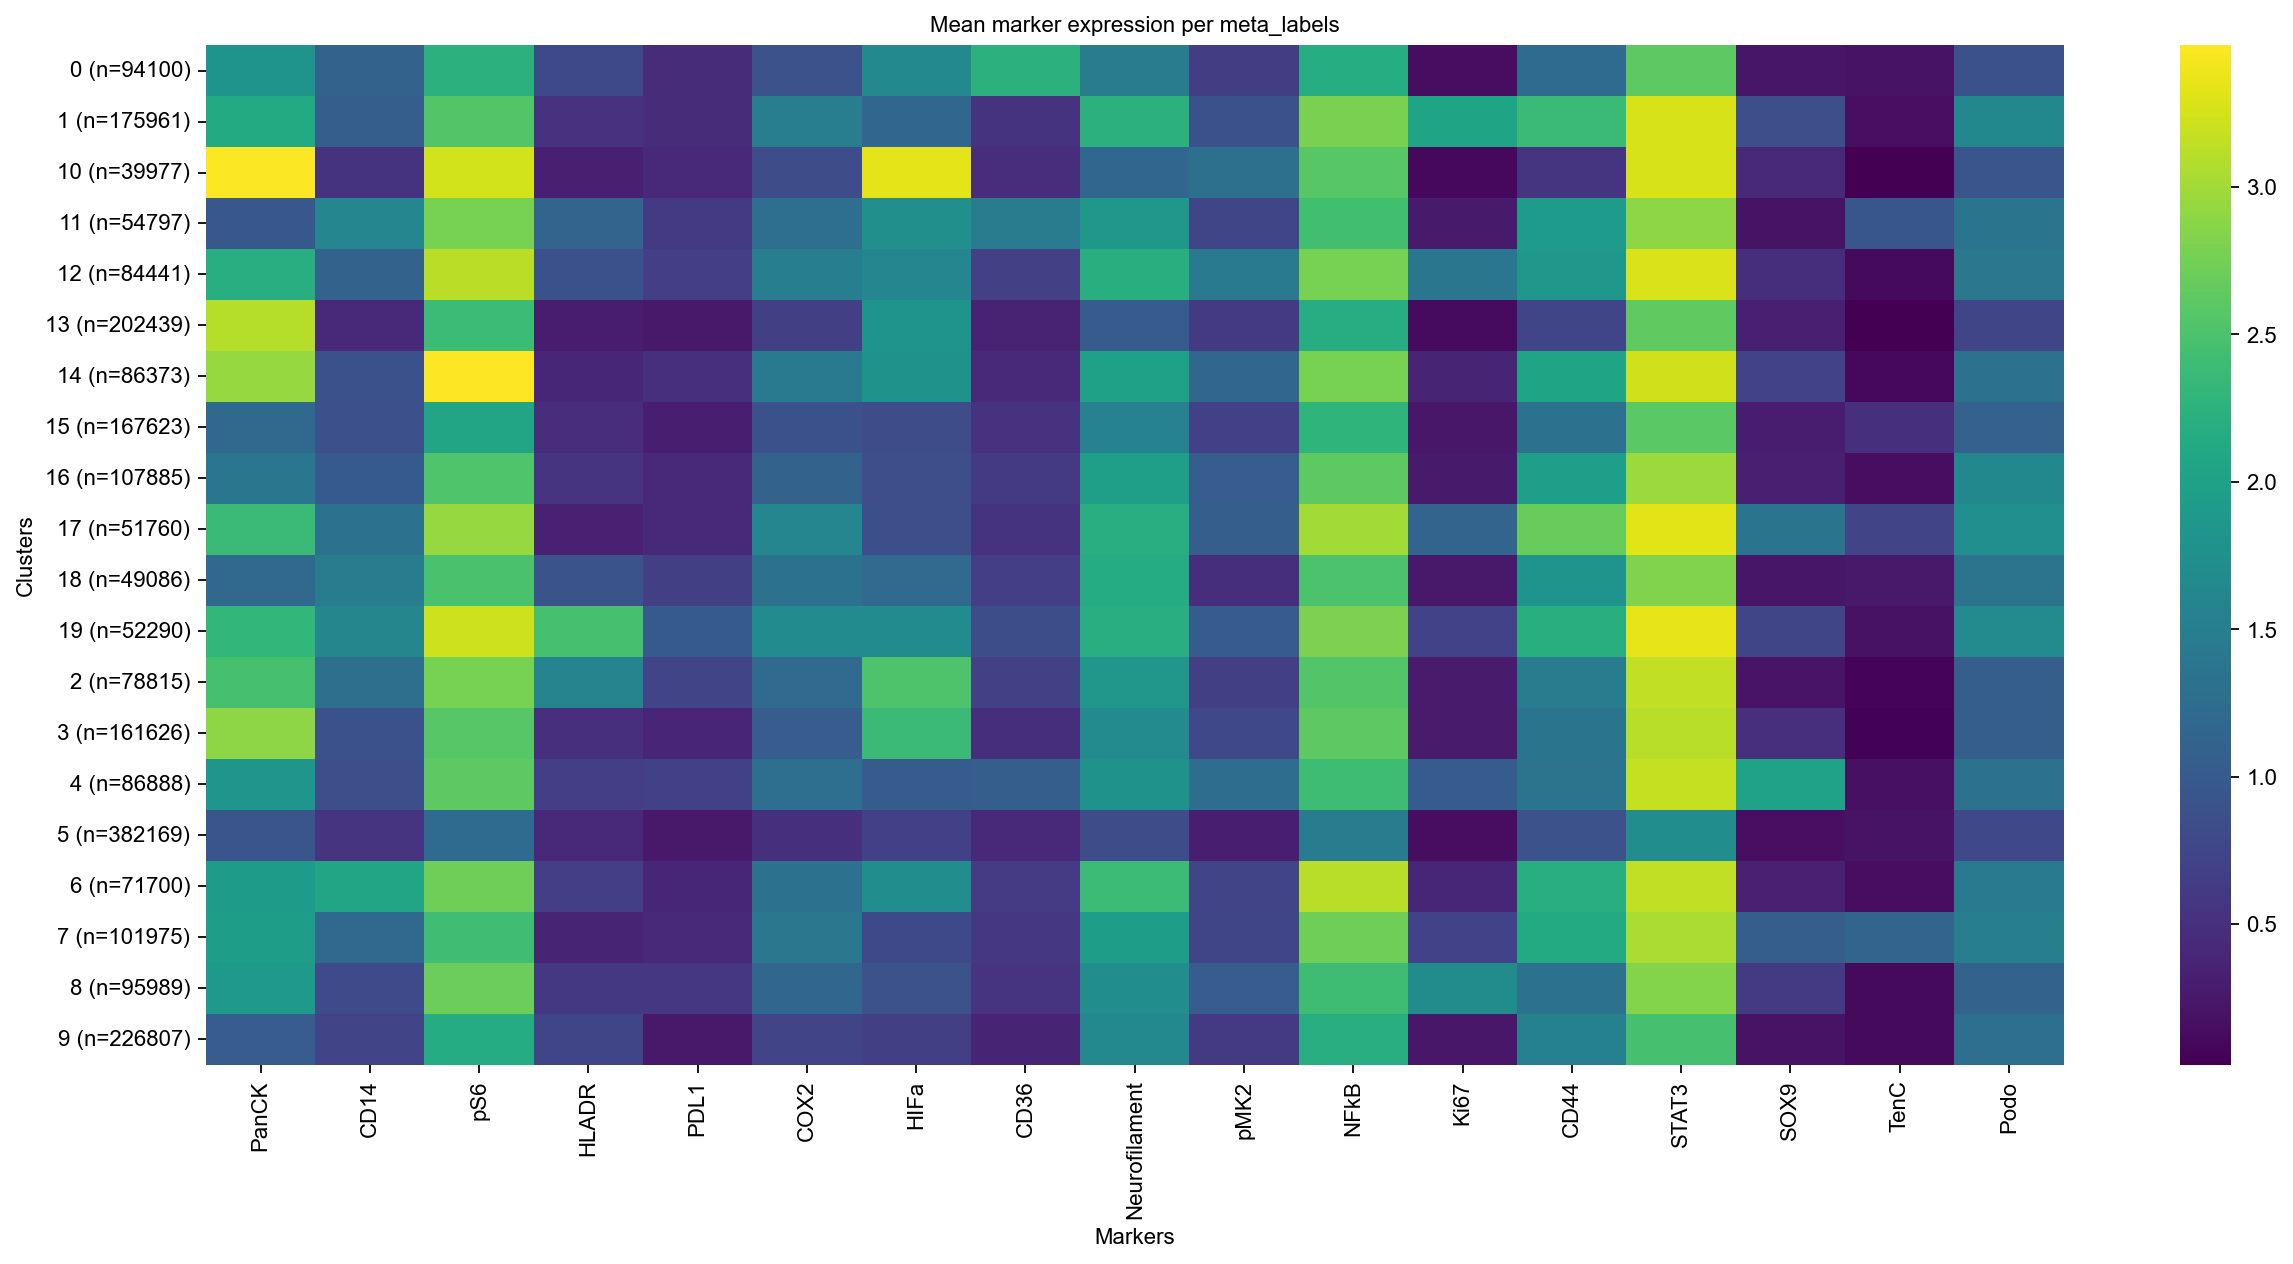

In [19]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from minisom import MiniSom
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import time

marker_list = ['PanCK',
 'CD14',
 'pS6',
 'HLADR',
 'PDL1',
 'COX2',
 'HIFa',
 'CD36',
 'Neurofilament',
 'pMK2',
 'NFkB',
 'Ki67',
 'CD44',
 'STAT3',
 'SOX9',
 'COX2',
 'TenC',
 'Podo',]

# --- Helper: subset AnnData by markers + condition ---
def create_subadata(adata, markers, use, filter_for=None):
    channel_mask = adata.var.index.isin(markers)

    if filter_for is not None:
        if isinstance(filter_for, list):
            cell_mask = adata.obs[use].isin(filter_for)
        else:
            cell_mask = adata.obs[use] == filter_for
    else:
        cell_mask = adata.obs[use].notna()

    X = np.arcsinh(adata.layers['counts'][cell_mask][:, channel_mask])
    
    return ad.AnnData(
        X=X, 
        var=adata.var[channel_mask].copy(), 
        obs=adata.obs[cell_mask].copy()
    )


# --- Main: SOM + meta-clustering ---
def apply_som_and_meta_clustering(adata, n_clusters=30, som_grid_size=(10, 10)):
    start_time = time.time()

    # 1. Scale
    print("Scaling data...")
    X = adata.X
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
    X_scaled = StandardScaler().fit_transform(X_scaled)

    # 2. SOM
    print(f"Training SOM grid={som_grid_size}...")
    som = MiniSom(som_grid_size[0], som_grid_size[1], X_scaled.shape[1],
                  sigma=1.0, learning_rate=0.5, random_seed=42)
    som.train_batch(X_scaled, 10000)

    # Map cells to SOM nodes
    som_clusters = np.array([som.winner(x)[0] * som_grid_size[1] + som.winner(x)[1] for x in X_scaled])

    # 3. Meta-clustering (KMeans on SOM nodes)
    print(f"Meta-clustering into {n_clusters} clusters...")
    som_node_positions = np.array([som.winner(x) for x in X_scaled])
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(som_node_positions)
    meta_labels = kmeans.labels_

    # Assign labels back to cells
    adata.obs['meta_labels'] = pd.Categorical(meta_labels.astype(str))

    print(f"Done. Total time: {time.time() - start_time:.2f} sec")
    return adata


# --- Plotting ---
def plot_expression_heatmap(adata, group_variable):
    df = pd.DataFrame(adata.X, columns=adata.var.index)
    df['Cluster'] = adata.obs[group_variable].values

    mean_exprs = df.groupby('Cluster').mean()
    counts = df['Cluster'].value_counts().reindex(mean_exprs.index)

    labels = [f"{c} (n={counts[c]})" for c in mean_exprs.index]

    plt.figure(figsize=(16, 8))
    sns.heatmap(mean_exprs, cmap="viridis", cbar=True, yticklabels=labels)
    plt.title(f"Mean marker expression per {group_variable}")
    plt.xlabel("Markers")
    plt.ylabel("Clusters")
    plt.tight_layout()
    plt.show()

tumorsubsets = data.obs['Celltype'].dropna().unique()  # all unique cell types
tumorsubsets = [ct for ct in tumorsubsets if "Tumor" in ct]

# --- Example usage ---
all_data = create_subadata(data, marker_list, use="Celltype", filter_for=tumorsubsets)
all_data = apply_som_and_meta_clustering(all_data, n_clusters=20, som_grid_size=(10, 10))
plot_expression_heatmap(all_data, group_variable="meta_labels")

In [70]:
# 2. Count cells per Image and Tumor subtype
counts = all_data.obs.groupby(["Image", "Celltype"]).size().reset_index(name="count")

# 3. Get total tumor cells per Image
totals = all_data.obs.groupby("Image").size().reset_index(name="total_tumor")

# 4. Merge totals into counts
counts = counts.merge(totals, on="Image")

# 5. Compute proportion (relative to tumor cells only)
counts["proportion"] = counts["count"] / counts["total_tumor"]

# 6. Add Recurrence info (one row per image)
counts = counts.merge(data.obs[["Image", "Recurrence_3yrs"]].drop_duplicates(), on="Image")

# 7. Plot boxplots: proportion of tumor subtypes by Recurrence
plt.figure(figsize=(10,6))
sns.boxplot(data=counts, x="meta_labels", y="proportion", hue="Recurrence_3yrs")
sns.stripplot(data=counts, x="meta_labels", y="proportion", hue="Recurrence_3yrs",
              dodge=True, alpha=0.5, linewidth=0.5)

plt.title("Relative proportion of Tumor cell subtypes per Image (grouped by Recurrence)")
plt.ylabel("Proportion of Tumor cells in image")
plt.xlabel("Recurrence")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `meta_labels` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x480 with 0 Axes>

In [5]:
data.obs['Sector'] = data.obs['Zone'].str.split("_").str[1]
data = assembling.add_metadata(data, base_dir=base_dir, metadata_files=['Outcomes_Stanford.xlsx','Outcomes_Tubingen.xlsx'], merge_on_column="Casenumber")

# Closest distance to celltype

In [72]:
# Coordinates
coords = data.obs[['Centroid-0', 'Centroid-1']].values  # shape (n_cells, 2)
celltypes = data.obs['Subtype'].values
targets = data.obs['Subtype'].unique()
images = data.obs['Image'].unique()

for t in tqdm(targets):
    target_coords = coords[celltypes == t]

    dist_to_target = np.full(len(data), np.nan)  # default NaN

    for img in tqdm(images):
        mask_img = data.obs["Image"] == img
        mask_target = mask_img & (celltypes == t)
        
        if mask_target.sum() < 2:
            continue  # no target cells in this image
        else:
            target_coords = coords[mask_target]
            tree = KDTree(target_coords)
            # query all cells in this image
            distances, _ = tree.query(coords[mask_img], k=2)
            dist_to_target[mask_img] = distances[:,1]

    data.obs[f'Dist_to_{t}'] = dist_to_target

100%|██████████| 28/28 [17:53<00:00, 38.34s/it]


In [85]:
cluster = pd.read_csv(os.path.join(base_dir, "Stabl", "dataframes", "clinical.csv"))

In [87]:
# unique Images in the same order as cluster_df
image_keys = cluster["Image"].values
cluster_vals = cluster["Cluster"].values

# factorize the image column once (very fast)
obs_img, unique_imgs = pd.factorize(data.obs["Image"].values)

# build lookup array aligned to unique_imgs
lookup = cluster_vals[pd.Index(image_keys).get_indexer(unique_imgs)]

# assign
data.obs["Cluster"] = lookup[obs_img]

# Neighborhood analysis

In [ ]:
def fast_neighbor_subtypes_for_image(
        adata,
        image_id,
        neighbors_dir,
        max_neighbors=10,
        max_distance=20,
    ):
    csv_path = None
    suffix = f"_{image_id}.csv"
    for f in os.listdir(neighbors_dir):
        if f.endswith(suffix):
            csv_path = os.path.join(neighbors_dir, f)
            break
    if csv_path is None:
        raise FileNotFoundError(f"No neighbor file ending with {suffix}")
    df = pd.read_csv(csv_path, usecols=["Object", "Neighbor", "Distance"])
    if max_distance is not None:
        df = df[df["Distance"] <= max_distance]

    if df.empty:
        return pd.DataFrame({"NeighborSubtypes": []})

    prefix = image_id + "_"
    df["Object_id"] = prefix + df["Object"].astype(str)
    df["Neighbor_id"] = prefix + df["Neighbor"].astype(str)

    img_mask = (adata.obs["Image"] == image_id)
    valid_ids = set(adata.obs_names[img_mask])

    df = df[df.Object_id.isin(valid_ids) & df.Neighbor_id.isin(valid_ids)]

    if df.empty:
        return pd.DataFrame({"NeighborSubtypes": []})

    subtype_map = adata.obs["Subtype"].to_dict()

    df.sort_values(["Object_id", "Distance"], inplace=True)

    df = df.groupby("Object_id", sort=False).head(max_neighbors)

    df["NeighborSubtype"] = df["Neighbor_id"].astype(str).map(subtype_map)

    out = (
        df.groupby("Object_id")["NeighborSubtype"]
          .apply(lambda x: x.tolist())
          .to_frame("NeighborSubtypes")
    )

    return out


def neighbor_list_to_proportions_fast(neighbor_df, adata):
    """
    Super-fast vectorized computation of neighbor subtype proportions.
    No Python loops. Works for hundreds of thousands of cells.
    """
    # All subtypes to include as columns
    all_subtypes = adata.obs["Subtype"].unique()

    # Step 1 — expand lists into rows (explode)
    exploded = neighbor_df["NeighborSubtypes"].explode()

    # Step 2 — count occurrences per (cell, subtype)
    counts = exploded.groupby([exploded.index, exploded]).size()

    # Step 3 — convert to wide matrix (one row per cell, one column per subtype)
    wide = counts.unstack(fill_value=0).reindex(columns=all_subtypes, fill_value=0)

    # Step 4 — divide by row sums (proportions)
    proportions = wide.div(wide.sum(axis=1), axis=0).fillna(0)

    # Step 5 — assign into adata.obs (fastest method)
    for subtype in all_subtypes:
        colname = f"Neighboring_{subtype}"
        adata.obs[colname] = 0.0  # ensure column exists
        if subtype in proportions.columns:
            adata.obs.loc[proportions.index, colname] = proportions[subtype]

    return adata


def process_all_image_neighbors(adata, neighbors_dir, max_neighbors=10, max_distance=20):

    all_dfs = []
    images = adata.obs["Image"].unique()
    for img in tqdm(images):
        df_img = fast_neighbor_subtypes_for_image(
            adata,
            image_id=img,
            neighbors_dir=neighbors_dir,
            max_neighbors=max_neighbors,
            max_distance=max_distance,
        )
        all_dfs.append(df_img)
    result = pd.concat(all_dfs)

    adata = neighbor_list_to_proportions_fast(result, adata)

    return adata

data = process_all_image_neighbors(data, os.path.join(base_dir, "neighbors"), max_neighbors=10, max_distance=50)

100%|██████████| 572/572 [1:56:06<00:00, 12.18s/it]


In [73]:
for col in data.obs.columns:
    if pd.api.types.is_datetime64_any_dtype(data.obs[col]):
        data.obs[col] = data.obs[col].astype(str)
data.write('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/12012025_annotdata.h5ad')